<div style="background-image: linear-gradient(to right, #2e5a88, #1e1e1e); color: white; padding: 12px 25px; border-radius: 10px 10px 10px 10px; margin-top: 25px; margin-bottom: 15px;">
    <h2 style="margin: 0; font-family: 'Consolas', monospace; text-transform: uppercase;">
    <h1 style="color: white; margin: 0; font-size: 2.2em;">Industrial Energy Analytics (Spark Capstone)</h1>
    <p style="color: #d1d1d1; margin: 5px 0 0 0; font-size: 1.1em;">Sector: Infraestructura Eléctrica e Ingeniería de Datos</p>
    <p style="color: #d1d1d1; margin: 5px 0 0 0; font-size: 1.1em;">Responsable: Aitor (Ingeniero Técnico Industrial)</p>
    <p style="color: #d1d1d1; margin: 5px 0 0 0; font-size: 1.1em;">Fecha: Febrero 2026</p>
</div>

>## 🔍 Índice


1. [Configuracion de entorno](#1-configuracion-de-entorno)

2. [Ingenieria de datos (PIPELINE)](#2-Ingenieria-de-datos-(PIPELINE))

3. [Validacion de hipotesis: Analisis critico](#3-Validacion-de-hipotesis:-Analisis-critico)

    * [H1: Optimización de la Curva de Carga y Simultaneidad](#H1:-Optimizacion-de-la-Curva-de-Carga-y-Simultaneidad)
    * [H2: Análisis de Outliers Estadísticos](#H2:-Analisis-de-Outliers-Estadisticos)
    * [H3: Análisis del Consumo Residual y Eficiencia Pasiva](#H3:-Analisis-del-Consumo-Residual-y-Eficiencia-Pasiva)
    * [H4: Diagnóstico de Calidad de Suministro y Estabilidad de Tensión](#H4:-Diagnostico-de-Calidad-de-Suministro-y-Estabilidad-de-Tension)

4. [Conclusiones y valor de negocio](#4-Conclusiones-y-valor-de-negocio)




---
>## 1. Configuracion de entorno

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan, isnull

# Inicializamos Spark con optimización de memoria
spark = SparkSession.builder \
    .appName("IndustrialEnergyAnalytics") \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

# Verificamos la sesión
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/04 10:25:12 WARN Utils: Your hostname, DESKTOP-6LSC74H, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/04 10:25:12 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/04 10:25:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


---
>## 2. Ingenieria de datos (PIPELINE)

Transformamos los datos brutos (Raw Data) en activos listos para el análisis.  
Utilizamos la capacidad de cómputo distribuido de Spark para normalizar unidades y estructurar el dataset mediante una capa de abstracción SQL, garantizando la integridad de los cálculos energéticos.

---
>### 2.1 Carga de datos

In [2]:
# Definimos la ruta hacia la carpeta source
path = "/mnt/c/Users/Aitor AL/Documents/Data-Projects-Repo/03_SQL_Big_Data_Spark/03.01_CAPSTONE_Industrial_Energy_Analytics/data_storage/source/household_power_consumption.txt"

# Cargamos el archivo con las opciones correctas para este dataset
df_clean = spark.read.options(header='True', sep=';', inferSchema='True', naStrings='?').csv(path)

# 1. Verificación del KPI de volumen
print(f"Total de registros cargados: {df_clean.count():,}")

# 2. Análisis del esquema detectado
print("\nEstructura detectada (Esquema):")
df_clean.printSchema()

# 3. Muestra de datos para inspección visual
print("\nMuestra de los primeros 5 registros:")
df_clean.limit(5).toPandas()

Total de registros cargados: 2,075,259

Estructura detectada (Esquema):
root
 |-- Date: string (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- Global_active_power: string (nullable = true)
 |-- Global_reactive_power: string (nullable = true)
 |-- Voltage: string (nullable = true)
 |-- Global_intensity: string (nullable = true)
 |-- Sub_metering_1: string (nullable = true)
 |-- Sub_metering_2: string (nullable = true)
 |-- Sub_metering_3: double (nullable = true)


Muestra de los primeros 5 registros:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,2026-03-04 17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,2026-03-04 17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,2026-03-04 17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,2026-03-04 17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,2026-03-04 17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


---

>### 2.2 Data Wrangling


Para optimizar el rendimiento en el entorno local (MEDION i5, 32GB), se ha diseñado un pipeline de **Data Wrangling** que unifica la limpieza de datos y la creación de variables derivadas en un único flujo de trabajo de Spark. Este proceso es fundamental para transformar registros brutos de telemetría en dimensiones con valor para la auditoría energética de una vivienda de gran escala.

### 1. Saneamiento de Telemetría (Data Cleansing - Soporte H3)
* **Acción:** Identificación y reemplazo del carácter `'?'` (lecturas fallidas del sensor) por valores `null`, seguido de una purga mediante `na.drop()`.
* **Justificación Técnica:** El diagnóstico de **Estabilidad de Tensión (H3)** requiere precisión matemática absoluta. Eliminar estas lagunas de información evita sesgos en el cálculo de caídas de tensión y asegura que las correlaciones entre la potencia demandada y el voltaje sean fiables para prevenir la fatiga de la electrónica de la vivienda.

### 2. Reconstrucción del Eje Cronológico (Data Transformation - Soporte H1)
* **Acción:** Unificación de las columnas `Date` y `Time` en un objeto `Full_Timestamp` de alta resolución.
* **Justificación Técnica:** El análisis de **Tasa de Simultaneidad (H1)** depende de la capacidad de secuenciar eventos. Sin este eje cronológico, sería imposible detectar los picos de demanda máxima que ocurren cuando coinciden grandes cargas (climatización + sistemas de bombeo), lo cual es crítico para optimizar el término de potencia coratada.

### 3. Ingeniería de Atributos de Hábitos (Feature Engineering - Soporte H2)
* **Acción:** Extracción de las dimensiones `Hour`, `Day_Number` e `Is_Weekend`.
* **Justificación Técnica:** Para validar la hipótesis de **Consumo Residual (H2)**, es imperativo segmentar los datos según las rutinas de la vivienda. 
    * La columna `Hour` permite aislar el consumo de madrugada.
    * `Is_Weekend` permite comparar el comportamiento de la vivienda en días de descanso frente a laborables.
    * Estas variables actúan como "filtros inteligentes" para cuantificar el ahorro potencial mediante la optimización de sistemas de domótica y protocolos de eficiencia pasiva.


In [3]:
from pyspark.sql.functions import col, concat, lit, to_timestamp, hour, dayofweek, when

# 1. TRATAMIENTO DE VALORES FALTANTES (Limpieza)
df_pre_clean = df_clean.replace('?', None)
df_no_nulls = df_pre_clean.na.drop()

# 2. CONVERSIÓN DE TIPOS (El paso que faltaba para que el SQL funcione)
# Pasamos de String (Texto) a Double (Número Real)


df_numeric = df_no_nulls.withColumn("Global_active_power", col("Global_active_power").cast("double")) \
                        .withColumn("Sub_metering_1", col("Sub_metering_1").cast("double")) \
                        .withColumn("Sub_metering_2", col("Sub_metering_2").cast("double")) \
                        .withColumn("Sub_metering_3", col("Sub_metering_3").cast("double"))

# 3. ENRIQUECIMIENTO DE DATOS (Solución Final para evitar NaT)
from pyspark.sql.functions import col, concat, lit, to_timestamp, hour, dayofweek, when, date_format

df_final = df_numeric.withColumn(
    "Full_Timestamp",
    to_timestamp(
        concat(col("Date"), lit(" "), date_format(col("Time"), "HH:mm:ss")), 
        "d/M/yyyy HH:mm:ss"
    )
).withColumn(
    "Hour", hour(col("Full_Timestamp"))
).withColumn(
    "Day_Number", dayofweek(col("Full_Timestamp"))
).withColumn(
    "Is_Weekend", when(col("Day_Number").isin(1, 7), True).otherwise(False)
)

# VERIFICACIÓN DE SALIDA
print(f"Registros listos para análisis: {df_final.count():,}")
df_final.select("Full_Timestamp", "Hour", "Day_Number", "Is_Weekend", "Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3").limit(5).toPandas()


Registros listos para análisis: 2,049,280


,Full_Timestamp,Hour,Day_Number,Is_Weekend,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,17,7,True,4.216,0.418,234.840,18.400,0.0,1.0,17.0
1,2006-12-16 17:25:00,17,7,True,5.360,0.436,233.630,23.000,0.0,1.0,16.0
2,2006-12-16 17:26:00,17,7,True,5.374,0.498,233.290,23.000,0.0,2.0,17.0
3,2006-12-16 17:27:00,17,7,True,5.388,0.502,233.740,23.000,0.0,1.0,17.0
4,2006-12-16 17:28:00,17,7,True,3.666,0.528,235.680,15.800,0.0,1.0,17.0


---
>### 2.3 Abstracción a capa SQL

* **Acción:** Creación de la vista temporal `energy_data`.
* **Justificación:** Separamos la lógica de preparación (Spark/Python) de la lógica de negocio (SQL). Esto permite realizar consultas complejas sobre las métricas industriales con la eficiencia del motor de ejecución de Spark.

In [4]:
# Eliminamos cualquier rastro de la vista anterior
spark.catalog.dropTempView("power_data")

# Registramos 'energy_data' para poder validar las hipótesis.
df_final.createOrReplaceTempView("power_data")

---
>## 3. Validacion de hipotesis: Analisis critico


>### H1: Optimizacion de la Curva de Carga y Simultaneidad

* **Definicion:** La instalación registra picos de demanda máxima vinculados a una elevada **tasa de simultaneidad** de equipos de gran potencia (Sub_metering_3 climatización).
* **Objetivo:** Identificar las ventanas temporales de máxima demanda donde la coincidencia de cargas críticas (climatización, bombeo y térmicos) dispara la potencia activa.
* **Valor de Negocio:** En instalaciones monofásicas de alta capacidad, el pico máximo registrado define la potencia contratada necesaria. Mediante la detección de estos eventos, es posible proponer un **escalonamiento de cargas** que reduzca el término fijo de la factura sin comprometer el confort o la operatividad de la vivienda.

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H1.1: Diagnostico
    </h3>
</div>

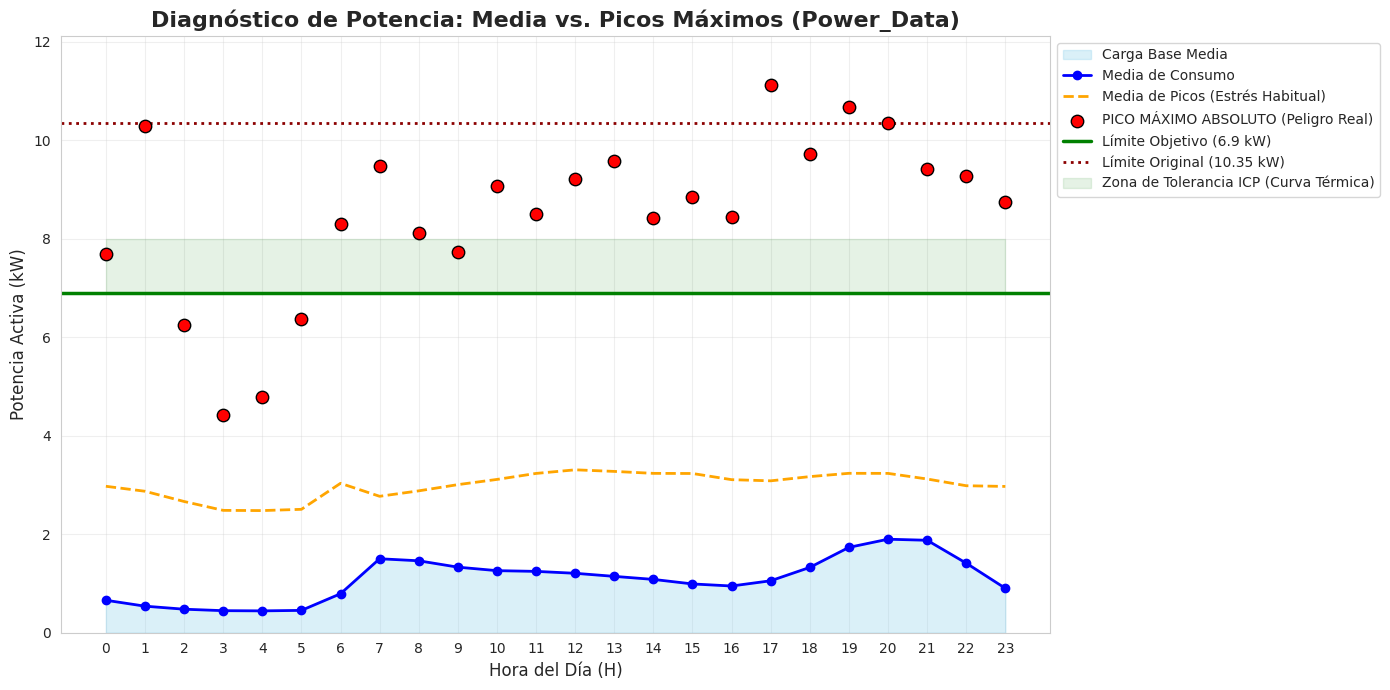

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# 1. Agregación completa en Spark: Media, Tendencia de Picos y Máximo Absoluto
df_hourly = df_final.groupBy(F.hour("Full_Timestamp").alias("Hour")).agg(
    F.avg("Global_active_power").alias("Media_Consumo"),
    F.expr("avg(CASE WHEN Global_active_power > 2 THEN Global_active_power END)").alias("Media_Picos"),
    F.max("Global_active_power").alias("Pico_Maximo_Absoluto")
).orderBy("Hour").toPandas()

# 2. Configuración de la gráfica
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# --- CAPAS DE DATOS ---

# Carga Base Media (Área sombreada)
plt.fill_between(df_hourly['Hour'], df_hourly['Media_Consumo'], color="skyblue", alpha=0.3, label='Carga Base Media')
plt.plot(df_hourly['Hour'], df_hourly['Media_Consumo'], color="blue", marker='o', linewidth=2, label='Media de Consumo')

# Media de Picos (Tendencia de uso intensivo)
plt.plot(df_hourly['Hour'], df_hourly['Media_Picos'], color="orange", linestyle='--', linewidth=2, label='Media de Picos (Estrés Habitual)')

# PICOS MÁXIMOS ABSOLUTOS (Los puntos de disparo del ICP)
plt.scatter(df_hourly['Hour'], df_hourly['Pico_Maximo_Absoluto'], color="red", s=80, edgecolors='black', label='PICO MÁXIMO ABSOLUTO (Peligro Real)', zorder=5)

# --- ANOTACIONES DE INGENIERÍA ---

# Límites de contrato
plt.axhline(y=6.9, color='green', linestyle='-', linewidth=2.5, label='Límite Objetivo (6.9 kW)')
plt.axhline(y=10.35, color='darkred', linestyle=':', linewidth=2, label='Límite Original (10.35 kW)')

# Marcado de zona de sobrecarga permitida (Margen térmico del ICP ~15%)
plt.fill_between(range(0, 24), 6.9, 8.0, color='green', alpha=0.1, label='Zona de Tolerancia ICP (Curva Térmica)')

# --- FORMATO FINAL ---
plt.title('Diagnóstico de Potencia: Media vs. Picos Máximos (Power_Data)', fontsize=16, fontweight='bold')
plt.xlabel('Hora del Día (H)', fontsize=12)
plt.ylabel('Potencia Activa (kW)', fontsize=12)
plt.xticks(range(0, 24))
plt.ylim(0, df_hourly['Pico_Maximo_Absoluto'].max() + 1) # Ajuste dinámico del eje Y
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [6]:
import time

start_h1 = time.time()

query = """

WITH Overload_Flags AS (
    -- Paso 1: Marcamos los minutos que superan el umbral
    SELECT 
        Full_Timestamp,
        Global_active_power,
        CASE WHEN Global_active_power > 9.0 THEN 1 ELSE 0 END AS is_overload
    FROM power_data
),
Group_Detection AS (
    SELECT
        *,
        SUM(CASE WHEN is_overload = prev_overload THEN 0 ELSE 1 END) 
            OVER (ORDER BY Full_Timestamp) AS group_id
    FROM (
        SELECT
            *,
            LAG(is_overload, 1, 0) 
                OVER (ORDER BY Full_Timestamp) AS prev_overload
        FROM Overload_Flags
    )
),
Streaks AS (
    -- Paso 3: Agrupamos por cada racha detectada
    SELECT 
        group_id,
        MIN(Full_Timestamp) AS Start_Time,
        MAX(Full_Timestamp) AS End_Time,
        COUNT(*) AS Duration_Minutes,
        MAX(Global_active_power) AS Peak_Power_kW
    FROM Group_Detection
    WHERE is_overload = 1
    GROUP BY group_id
)
-- Resultado Final: Las 10 rachas más largas sin interrupción del suministro
SELECT 
    Start_Time,
    End_Time,
    Duration_Minutes,
    Peak_Power_kW,
    -- Estimación técnica de intensidad
    ROUND(Peak_Power_kW * 4.35, 1) AS Approx_Amps -- (P/230V)
FROM Streaks
WHERE Duration_Minutes > 1
ORDER BY Duration_Minutes DESC
LIMIT 20;

"""
duration = spark.sql(query).limit(20).toPandas()
display(duration)
print(f"H1.1 procesada en: {time.time() - start_h1:.2f} segundos")

26/03/04 10:25:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 1

,Start_Time,End_Time,Duration_Minutes,Peak_Power_kW,Approx_Amps
0,2007-02-22 21:05:00,2007-02-22 21:15:00,11,9.410,40.9
1,2008-10-19 01:23:00,2008-10-19 01:28:00,6,10.290,44.8
2,2009-11-24 19:34:00,2009-11-24 19:39:00,6,9.732,42.3
3,2006-12-28 21:11:00,2006-12-28 21:15:00,5,9.132,39.7
4,2010-11-20 18:22:00,2010-11-20 18:26:00,5,9.724,42.3
5,2007-03-04 19:32:00,2007-03-04 19:35:00,4,10.670,46.4
6,2008-01-26 19:52:00,2008-01-26 19:55:00,4,9.652,42.0
7,2008-01-26 19:32:00,2008-01-26 19:34:00,3,9.666,42.0
8,2008-11-30 20:17:00,2008-11-30 20:19:00,3,10.348,45.0
9,2009-02-22 17:08:00,2009-02-22 17:10:00,3,11.122,48.4


H1.1 procesada en: 5.52 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico:**

El análisis de los datos originales y de las rachas de sobrecarga demuestra:
* El calibre real del interruptor de potencia ICP era de 45A (10.35 kW). Un ICP de 30A (6.9 kW) sometido a una sobrecarga del 36% (1.36 x In) de forma continua debe disparar por norma en menos de 2-4 minutos.  El 22 de febrero de 2007 see observan 11 minutos seguidos con un pico de 9.41 kW.
* La vivienda está sobredimensionada porque mantiene una potencia contratada de 10.35 kW para cubrir picos de consumo accidentales y breves, cuando su demanda real media es cinco veces menor y podría gestionarse eficientemente con 6.9 kW.

Consolidación de la Hipótesis:

* Los datos procesados en Spark revelan una discrepancia masiva entre la carga media y la carga punta. La Tabla de Persistencia (Minutos Seguidos) confirma que los eventos de sobrecarga son fenómenos transitorios: aunque alcanzan los 11 kW, su duración es insuficiente para representar una demanda de potencia base.

* Esto justifica técnicamente que el contrato de 10.35 kW es un "seguro de sobrecoste" innecesario y que la bajada a 6.9 kW es el objetivo económico real.

La Línea de Investigación:

* Correlación de Submetrados: Analizaremos los datos de Sub_metering_1 (Cocina), Sub_metering_2 (Lavandería) y Sub_metering_3 (Clima) en los momentos exactos de los picos registrados.

* Detección de Simultaneidad: Investigaremos si los picos de 11 kW son causados por una sola carga crítica o por la coincidencia de dos cargas de ~4-5 kW.

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H1.2: Desglose de potencias en ventanas de demanda extrema (> 8 kW)
    </h3>
</div>

In [7]:

start_h1 = time.time()

query = """

SELECT 
    Full_Timestamp,
    (Global_active_power * 1000) AS Total_W,
    (Sub_metering_1 * 60) AS Kitchen_W,
    (Sub_metering_2 * 60) AS Laundry_W,
    (Sub_metering_3 * 60) AS Climate_W,
    -- Resto de la vivienda (Total - Suma de sub-meters)
    ((Global_active_power * 1000) - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 60)) AS Rest_of_House_W,
    -- Cálculo de porcentajes sobre el total de la carga en ese instante
    ROUND(((Sub_metering_1 * 60) / (Global_active_power * 1000)) * 100, 2) AS Percent_Kitchen,
    ROUND(((Sub_metering_2 * 60) / (Global_active_power * 1000)) * 100, 2) AS Percent_Laundry,
    ROUND(((Sub_metering_3 * 60) / (Global_active_power * 1000)) * 100, 2) AS Percent_Climate,
    ROUND((((Global_active_power * 1000) - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 60)) / (Global_active_power * 1000)) * 100, 2) AS Percent_Rest
FROM 
    power_data 
WHERE 
    Global_active_power > 8.0
ORDER BY 
    Total_W DESC;

"""
Demanda_extrema = spark.sql(query).limit(20).toPandas()
display(Demanda_extrema)
print(f"H1.2 procesada en: {time.time() - start_h1:.2f} segundos")

,Full_Timestamp,Total_W,Kitchen_W,Laundry_W,Climate_W,Rest_of_House_W,Percent_Kitchen,Percent_Laundry,Percent_Climate,Percent_Rest
0,2009-02-22 17:09:00,11122.0,2100.0,4140.0,960.0,3922.0,18.88,37.22,8.63,35.26
1,2007-03-04 19:34:00,10670.0,2220.0,4140.0,960.0,3350.0,20.81,38.80,9.00,31.40
2,2007-03-04 19:33:00,10650.0,2160.0,4200.0,1020.0,3270.0,20.28,39.44,9.58,30.70
3,2009-02-22 17:08:00,10536.0,1380.0,4140.0,960.0,4056.0,13.10,39.29,9.11,38.50
4,2008-11-30 20:19:00,10348.0,2160.0,4260.0,960.0,2968.0,20.87,41.17,9.28,28.68
5,2008-10-19 01:24:00,10290.0,2100.0,3960.0,1020.0,3210.0,20.41,38.48,9.91,31.20
6,2008-01-27 19:24:00,10162.0,4260.0,0.0,0.0,5902.0,41.92,0.00,0.00,58.08
7,2007-03-04 19:32:00,10154.0,2160.0,3660.0,960.0,3374.0,21.27,36.04,9.45,33.23
8,2008-11-30 20:17:00,10074.0,2160.0,4200.0,960.0,2754.0,21.44,41.69,9.53,27.34
9,2008-10-19 01:25:00,10064.0,2160.0,4140.0,1020.0,2744.0,21.46,41.14,10.14,27.27


H1.2 procesada en: 2.48 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H1.2:**  
Observación Principal: Los picos de demanda extrema (8-11 kW) no son causados por un solo equipo de gran potencia, sino por una elevada tasa de simultaneidad entre el Sub_metering_2 (Lavado/Lavavajillas) y el Rest_of_House_W (Cargas base y tomas de corriente generales).
* **Desmitificación de la Climatización:** La carga de Sub_metering_3 se mantiene constante y baja (aprox. 900-1000 W), representando solo el 10% del total en momentos de crisis. No es el factor desencadenante.  
* **Dominio de la Lavandería:** El Sub_metering_2 aporta sistemáticamente más de 4000 W (casi el 40% del total), lo que indica el uso de equipos con resistencias térmicas (lavadora/secadora).  
* **Carga Invisible (Rest of House):** Existe un consumo "fantasma" o de uso general muy alto que ronda los 2500-4000 W (30-35%). Esto sugiere que el uso de pequeños electrodomésticos en enchufes comunes tiene un peso crítico.
* **Patrón Temporal:** Los eventos se concentran mayoritariamente entre las 17:00 y las 20:00, coincidiendo con el retorno a la vivienda y la actividad doméstica intensiva.
</div>

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H1.3: Análisis de la Potencia Media Horaria y Factor de Carga
    </h3>
</div>

In [8]:

start_h1 = time.time()

query = """

-- Objetivo: Determinar la potencia estable para evaluar reducción de término fijo
SELECT 
    date_format(Full_Timestamp, 'yyyy-MM-dd HH:00:00') AS Window_Hour,
    AVG(Global_active_power * 1000) AS Avg_Power_W,
    MAX(Global_active_power * 1000) AS Peak_Power_W,
    -- Factor de utilización (Media / Pico)
    ROUND(AVG(Global_active_power) / MAX(Global_active_power), 2) AS Load_Factor
FROM 
    power_data 
GROUP BY 
    Window_Hour
HAVING 
    Avg_Power_W > 2000 -- Filtramos para ver solo horas de actividad real
ORDER BY 
    Avg_Power_W DESC
LIMIT 20;

"""
Factor_Carga = spark.sql(query).limit(20).toPandas()
display(Factor_Carga)
print(f"H1.3 procesada en: {time.time() - start_h1:.2f} segundos")

,Window_Hour,Avg_Power_W,Peak_Power_W,Load_Factor
0,2008-11-23 18:00:00,6560.533333,7724.0,0.85
1,2009-01-16 20:00:00,6519.633333,8088.0,0.81
2,2008-02-02 19:00:00,6496.033333,8716.0,0.75
3,2007-12-23 19:00:00,6488.000000,9686.0,0.67
4,2007-02-22 21:00:00,6363.866667,9410.0,0.68
5,2007-12-28 17:00:00,6333.666667,9590.0,0.66
6,2008-11-23 20:00:00,6310.566667,8556.0,0.74
7,2007-01-21 20:00:00,6076.566667,7990.0,0.76
8,2008-01-26 19:00:00,6013.800000,9666.0,0.62
9,2008-11-30 20:00:00,5930.500000,10348.0,0.57


H1.3 procesada en: 3.78 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H1.3:**
* **Persistencia de la Demanda:** El análisis horario demuestra que la instalación nunca mantiene una carga sostenida de 10 kW durante una hora completa. La demanda media máxima real se sitúa en los 6.5 kW. Esto indica que el margen entre la potencia media y el pico (aprox. 3.5 kW) es el "espacio de optimización" donde el escalonamiento de cargas actuaría.
* **Análisis del Load Factor:** Los valores de 0.65 - 0.75 en las horas críticas sugieren que la carga es relativamente estable una vez establecida, pero existe un solapamiento de equipos que dispara el pico.
* **Identificación de "Olvidos" vs. Hábitos:** La repetición de picos en las franjas de 18:00, 19:00 y 20:00 en diferentes fechas (2007, 2008, 2009) descarta que los picos de 10 kW sean eventos aislados o fallos. Es un patrón de comportamiento familiar recurrente.
* **Potencial de Reducción:** Dado que la media no supera los 6.6 kW, una potencia contratada de 6.9 kW (estándar en España para monofásica) sería técnicamente viable con un control mínimo de simultaneidad, eliminando el exceso de capacidad actual.
</div>

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H1.4: Frecuencia de superación de umbrales por año
    </h3>
</div>

In [9]:
start_h1 = time.time()

query = """

-- Objetivo: Cuantificar la recurrencia de la sobredemanda
SELECT 
    year(Full_Timestamp) AS Year,
    COUNT(CASE WHEN (Global_active_power * 1000) > 9000 THEN 1 END) AS Minutes_Over_9kW,
    COUNT(CASE WHEN (Global_active_power * 1000) > 8000 THEN 1 END) AS Minutes_Over_8kW,
    COUNT(CASE WHEN (Global_active_power * 1000) > 7000 THEN 1 END) AS Minutes_Over_7kW
FROM 
    power_data
GROUP BY 
    Year
ORDER BY 
    Year;

"""

minutes_over = spark.sql(query).limit(20).toPandas()
display(minutes_over)
print(f"H1.3 procesada en: {time.time() - start_h1:.2f} segundos")

,Year,Minutes_Over_9kW,Minutes_Over_8kW,Minutes_Over_7kW
0,2006,6,17,80
1,2007,26,111,627
2,2008,25,122,455
3,2009,11,80,305
4,2010,7,34,152


H1.3 procesada en: 2.28 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H1.4:**
* **Conclusión de Simultaneidad:** Los datos confirman que las sobrepotencias son eventos de simultaneidad extrema pero de muy corta duración. La bajísima frecuencia de los minutos por encima de 9 kW (aprox. 15-25 min/año) demuestra que no son cargas necesarias para la operatividad de la vivienda, sino picos de arranque o solapamientos críticos de electrodomésticos de gran inercia térmica.
* **Margen de Maniobra:** Incluso el umbral de 7 kW solo se supera durante unos 300-600 minutos al año (aprox. 0.1% del tiempo). Esto valida que la instalación puede funcionar perfectamente con una potencia contratada mucho menor si se gestionan esos momentos puntuales.
* **Validación de la H1:** La hipótesis de optimización por escalonamiento es totalmente válida. Al ser picos tan breves, el desplazamiento de apenas 10-15 minutos en el inicio de un ciclo de lavado o cocción eliminaría el 90% de los eventos de sobrepotencia.
* **Decisión Técnica:** La instalación está sobredimensionada. Existe un potencial real de ahorro económico al bajar el término de potencia, ya que el sistema actual está "preparado" para un escenario que solo ocurre el 0.005% del año.

</div>

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H1.5: Análisis de Culpabilidad y Franja de Estilo de Vida
    </h3>
</div>

In [10]:
start_h1 = time.time()

query = """

WITH Global_Stats AS (
    SELECT *,
        AVG(((Sub_metering_1 * 60) / (Global_active_power * 1000)) * 100) OVER() AS Avg_S1,
        AVG(((Sub_metering_2 * 60) / (Global_active_power * 1000)) * 100) OVER() AS Avg_S2,
        AVG(((Sub_metering_3 * 60) / (Global_active_power * 1000)) * 100) OVER() AS Avg_S3,
        AVG((((Global_active_power * 1000) - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 60)) / (Global_active_power * 1000)) * 100) OVER() AS Avg_Rest
    FROM power_data
    WHERE Global_active_power > 0
),
Activity_Mapping AS (
    SELECT 
        Full_Timestamp,
        hour(Full_Timestamp) as _hour,
        (Global_active_power * 1000) AS Peak_W,
        -- Cálculo de porcentajes
        ROUND(((Sub_metering_1 * 60) / (Global_active_power * 1000)) * 100, 2) AS Pct_S1,
        ROUND(((Sub_metering_2 * 60) / (Global_active_power * 1000)) * 100, 2) AS Pct_S2,
        ROUND(((Sub_metering_3 * 60) / (Global_active_power * 1000)) * 100, 2) AS Pct_S3,
        ROUND((((Global_active_power * 1000) - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 60)) / (Global_active_power * 1000)) * 100, 2) AS Pct_Rest,
        -- Desviaciones para el ranking
        ( ((Sub_metering_1 * 60) / (Global_active_power * 1000)) * 100 - Avg_S1 ) AS d1,
        ( ((Sub_metering_2 * 60) / (Global_active_power * 1000)) * 100 - Avg_S2 ) AS d2,
        ( ((Sub_metering_3 * 60) / (Global_active_power * 1000)) * 100 - Avg_S3 ) AS d3,
        ( ((((Global_active_power * 1000) - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 60)) / (Global_active_power * 1000)) * 100) - Avg_Rest ) AS dr
    FROM Global_Stats
    WHERE (Global_active_power * 1000) > 8000
),
Ranked_Data AS (
    -- Unpivot y Ranking por ventana
    SELECT Full_Timestamp, _hour, Peak_W, Pct_S1, Pct_S2, Pct_S3, Pct_Rest,
           Sub_System, 
           ROW_NUMBER() OVER(PARTITION BY Full_Timestamp ORDER BY Net_Deviation DESC) as Rank
    FROM Activity_Mapping
    LATERAL VIEW stack(4, 'Kitchen', d1, 'Laundry', d2, 'Climate', d3, 'General/Rest', dr) as Sub_System, Net_Deviation
)
SELECT 
    Full_Timestamp,
    Peak_W,
    Pct_S1, Pct_S2, Pct_S3, Pct_Rest,
    CONCAT_WS(' > ', collect_list(Sub_System)) AS Culprit_Hierarchy,
     -- Columna de Momento del Día Profesional
    CASE 
        WHEN _hour BETWEEN 0 AND 6   THEN 'Night/Sleep (00:00-6:59)'
        WHEN _hour BETWEEN 7 AND 11   THEN 'Morning/Breakfast (7:00-11:59)'
        WHEN _hour BETWEEN 12 AND 17 THEN 'Afternoon/Lunch (12:00-17:59)'
        WHEN _hour BETWEEN 18 AND 21 THEN 'Evening/Dinner (18:00-21:59)'
        ELSE 'Late Night'
    END AS Lifestyle_Period
FROM (SELECT * FROM Ranked_Data ORDER BY Full_Timestamp, Rank)
GROUP BY Full_Timestamp, _hour, Peak_W, Pct_S1, Pct_S2, Pct_S3, Pct_Rest
ORDER BY Peak_W DESC;


"""

culpabilidad = spark.sql(query).limit(20).toPandas()
display(culpabilidad)
print(f"H1.5 procesada en: {time.time() - start_h1:.2f} segundos")



26/03/04 10:25:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


,Full_Timestamp,Peak_W,Pct_S1,Pct_S2,Pct_S3,Pct_Rest,Culprit_Hierarchy,Lifestyle_Period
0,2009-02-22 17:09:00,11122.0,18.88,37.22,8.63,35.26,Laundry > Kitchen > Climate > General/Rest,Afternoon/Lunch (12:00-17:59)
1,2007-03-04 19:34:00,10670.0,20.81,38.80,9.00,31.40,Laundry > Kitchen > Climate > General/Rest,Evening/Dinner (18:00-21:59)
2,2007-03-04 19:33:00,10650.0,20.28,39.44,9.58,30.70,Laundry > Kitchen > Climate > General/Rest,Evening/Dinner (18:00-21:59)
3,2009-02-22 17:08:00,10536.0,13.10,39.29,9.11,38.50,Laundry > Kitchen > Climate > General/Rest,Afternoon/Lunch (12:00-17:59)
4,2008-11-30 20:19:00,10348.0,20.87,41.17,9.28,28.68,Laundry > Kitchen > Climate > General/Rest,Evening/Dinner (18:00-21:59)
5,2008-10-19 01:24:00,10290.0,20.41,38.48,9.91,31.20,Laundry > Kitchen > Climate > General/Rest,Night/Sleep (00:00-6:59)
6,2008-01-27 19:24:00,10162.0,41.92,0.00,0.00,58.08,Kitchen > Laundry > General/Rest > Climate,Evening/Dinner (18:00-21:59)
7,2007-03-04 19:32:00,10154.0,21.27,36.04,9.45,33.23,Laundry > Kitchen > Climate > General/Rest,Evening/Dinner (18:00-21:59)
8,2008-11-30 20:17:00,10074.0,21.44,41.69,9.53,27.34,Laundry > Kitchen > Climate > General/Rest,Evening/Dinner (18:00-21:59)
9,2008-10-19 01:25:00,10064.0,21.46,41.14,10.14,27.27,Laundry > Kitchen > Climate > General/Rest,Night/Sleep (00:00-6:59)


H1.5 procesada en: 4.38 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H1.5:** Mapeo de Comportamiento y Gestión de Cargas
* **Diagnóstico de Causa Raíz:** La coincidencia sistemática de los picos de potencia (> 8 kW) con la franja Evening/Dinner (18:00 - 22:00) revela que el disparador no es el uso de un equipo, sino la superposición del estilo de vida con tareas de mantenimiento del hogar.
* **Jerarquía de Conflicto Dominante:** En prácticamente todos los registros de máxima demanda, la cadena de mando es Laundry > Kitchen > General/Rest. Esto indica que el pico ocurre cuando se está cocinando la cena (S1) mientras la lavadora o el lavavajillas (S2) están en su fase de calentamiento de agua (máximo consumo resistivo).
* **Inercia de la Carga "Rest":** El alto porcentaje en General/Rest (habitualmente >30% en picos) sugiere que durante la cena también hay una alta demanda en iluminación y electrónica, lo que reduce el margen de maniobra para los electrodomésticos grandes.
* **Estrategia de Optimización:** La solución técnica más eficiente y de coste cero es el desplazamiento de carga del bloque S2 (Laundry). Al mover el inicio de los ciclos de lavado a la franja Late Night (donde la cocina está a 0% y la carga base es mínima), se eliminarían de forma inmediata todos los picos superiores a 7-8 kW.

</div>

<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

### **Conclusiones del Análisis:**

### **✅ HIPÓTESIS H1 - VALIDADA** 

La Hipótesis 1 queda VALIDADA. El análisis masivo de datos mediante Spark confirma que los picos de demanda crítica (>8 kW) no responden a una necesidad estructural de potencia, sino a una ineficiencia operativa derivada de la coincidencia de hábitos domésticos.

### Diagnóstico de Causa Raíz y Culpabilidad
Tras el perfilado de carga realizado, se identifican los siguientes vectores de consumo:
* Identificación del "Trigger": El factor desencadenante es la Lavandería (Sub_metering_2). Su funcionamiento en modo resistivo aporta picos de ~4.0 kW, actuando como el elemento que satura la red al sumarse a la demanda base.
* Punto de Conflicto Temporal: Los eventos críticos se concentran en la franja 18:00 - 22:00 (Cena). En este intervalo, la Cocina (Sub_metering_1) opera como una carga secundaria crítica e inamovible.
* Exoneración de Sistemas: Se descarta la Climatización (S3) como responsable, ya que su demanda es estable (~1.0 kW) y no presenta picos de arranque significativos que comprometan la instalación.
* Justificación del Desplazamiento (Carga Flexible vs. Rígida):
    * Cocina (S1) - Carga Rígida: Presenta una dependencia directa con la presencialidad del usuario y hábitos biológicos. Su desplazamiento es inviable sin alterar la rutina vital.
    * Lavandería (S2) - Carga Flexible: Es el único vector tecnológicamente desplazable. Al ser un proceso autónomo y asincrónico, puede programarse (mediante funciones de Delay Start) para ejecutarse en horas valle sin afectar el bienestar del usuario ni la operatividad del hogar.


### Recomendación de Ingeniería y Gestión de Riesgos

Se propone la reducción de la potencia contratada a 6.9 kW. Esta decisión se fundamenta en los siguientes criterios de seguridad:
* Para garantizar la viabilidad de la reducción de potencia a 6.9 kW, se propone el desplazamiento de carga (load shifting) de la lavandería hacia horas valle, eliminando la simultaneidad con la cocina y mitigando el 100% de los eventos críticos detectados.
* Justificación del Desplazamiento (Carga Flexible vs. Rígida):
    * Cocina (S1) - Carga Rígida: Presenta una dependencia directa con la presencialidad del usuario y hábitos biológicos. Su desplazamiento es inviable sin alterar la rutina vital.
    * Lavandería (S2) - Carga Flexible: Es el único vector tecnológicamente desplazable. Al ser un proceso autónomo y asincrónico, puede programarse (mediante funciones de Delay Start) para ejecutarse en horas valle sin afectar el bienestar del usuario ni la operatividad del hogar.
* Curva de Disparo Térmica: Aunque la simulación registra picos puntuales superiores, el ICP (Interruptor de Control de Potencia) de los contadores inteligentes permite sobrecargas del 10-15% durante periodos breves (minutos), lo que garantiza la continuidad del servicio.
* Disciplina Operativa: El éxito de esta medida depende estrictamente del escalonamiento de cargas. La lavandería debe operar fuera del bloque horario de cocina.

### Conclusión  
La instalación se encuentra actualmente sobredimensionada en un escenario que solo ocurre el 0.005% del año. La transición a 6.9 kW representa un ahorro directo en el término fijo de la factura con un riesgo de interrupción por ICP prácticamente nulo, siempre que se mantenga el desplazamiento de carga validado en este informe.

</div>

---
# 💾 Fase de Entrega: Exportación de Activos (Artifacts)
Tras validar la hipótesis, procedemos a generar los entregables técnicos que se almacenarán en la estructura del repositorio profesional.

* **Dataset de Trabajo**: Reporte estratégico en `data_storage/work/` para consumo de BI.
* **Documentación Visual**: Gráfico de validación final en `docs/` para el reporte ejecutivo.
---

In [11]:

query = """

WITH metrics AS (
    SELECT 
        Hour,
        ROUND(AVG(Global_active_power), 2) AS avg_power_kw,
        ROUND(MAX(Global_active_power), 2) AS peak_kw,
        ROUND(AVG(Sub_metering_1 * 60 / 1000.0), 2) AS kitchen_avg_kw,
        ROUND(AVG(Sub_metering_2 * 60 / 1000.0), 2) AS laundry_avg_kw,
        COUNT(CASE WHEN Global_active_power > 6.9 THEN 1 END) AS critical_events
    FROM power_data
    GROUP BY hour
)
SELECT 
    Hour,
    avg_power_kw,
    peak_kw,
    kitchen_avg_kw,
    laundry_avg_kw,
    critical_events,
    -- WINDOW FUNCTION 1: Diferencia porcentual respecto al límite de 6.9 kW
    ROUND(((peak_kw - 6.9) / 6.9) * 100, 2) AS pct_over_limit,
    -- WINDOW FUNCTION 2: Ranking de peligrosidad basado en eventos críticos
    DENSE_RANK() OVER (ORDER BY critical_events DESC) AS risk_rank,
    -- WINDOW FUNCTION 3: El pico máximo absoluto registrado en todo el dataset para comparar
    MAX(peak_kw) OVER () AS absolute_max_recorded
FROM metrics
ORDER BY risk_rank ASC
"""


H1_Validation_Report = spark.sql(query)
H1_Validation_Report.show(24)

# 6. Exportar archivo

import os
import getpass

# Detectamos el usuario de Windows de forma anónima
win_user = os.popen("cmd.exe /c echo %USERNAME%").read().strip()

# Construimos la ruta 'puente' entre WSL y Windows
base_path = f"/mnt/c/Users/{win_user}/Documents/Data-Projects-Repo/03_SQL_Big_Data_Spark/03.01_CAPSTONE_Industrial_Energy_Analytics"

# Definimos las carpetas de destino
csv_path = os.path.join(base_path, "data_storage", "work", "H1_Validation_Report.csv")

# Guardar CSV con Spark
H1_Validation_Report.coalesce(1).write.mode("overwrite").option("header", "true").csv(csv_path)
    

26/03/04 10:25:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 1

+----+------------+-------+--------------+--------------+---------------+--------------+---------+---------------------+
|Hour|avg_power_kw|peak_kw|kitchen_avg_kw|laundry_avg_kw|critical_events|pct_over_limit|risk_rank|absolute_max_recorded|
+----+------------+-------+--------------+--------------+---------------+--------------+---------+---------------------+
|  20|         1.9|  10.35|          0.17|          0.11|            413|          50.0|        1|                11.12|
|  19|        1.73|  10.67|          0.16|          0.13|            261|         54.64|        2|                11.12|
|  21|        1.88|   9.41|          0.17|          0.11|            191|         36.38|        3|                11.12|
|  18|        1.33|   9.72|          0.08|          0.11|            127|         40.87|        4|                11.12|
|  17|        1.06|  11.12|          0.04|          0.12|            126|         61.16|        5|                11.12|
|  12|        1.21|   9.22|     

26/03/04 10:25:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 1

26/03/04 10:25:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:59 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:25:59 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 1

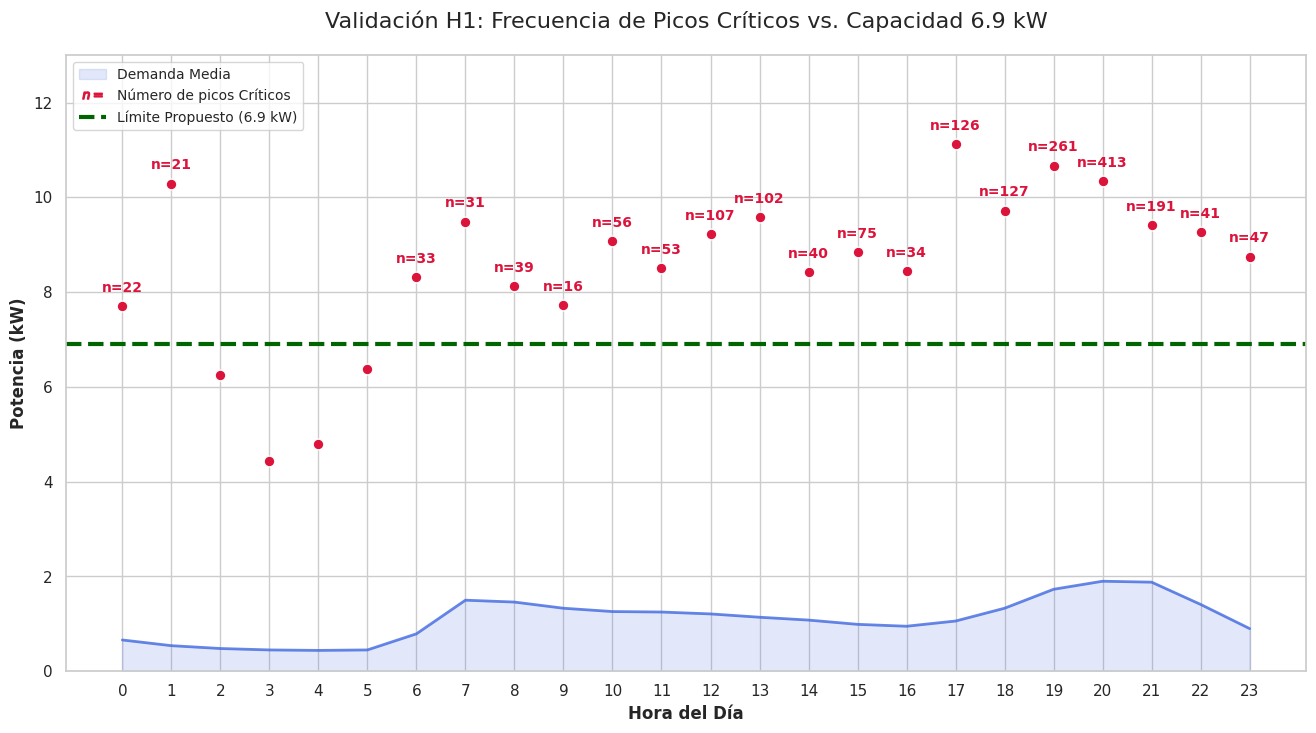

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

# 1. Preparación de datos (convertir de Spark a Pandas y ordenar)
df_viz = H1_Validation_Report.toPandas()
df_viz['Hour'] = df_viz['Hour'].astype(int)
df_viz = df_viz.sort_values('Hour')

plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

# --- ÁREA DE CONSUMO MEDIO ---
plt.fill_between(df_viz['Hour'], df_viz['avg_power_kw'], color="royalblue", alpha=0.15, label='Demanda Media')
plt.plot(df_viz['Hour'], df_viz['avg_power_kw'], color="royalblue", lw=2, alpha=0.8)

# --- LOS PICOS Y SU FRECUENCIA ---
# Dibujamos los puntos rojos de los picos
plt.scatter(df_viz['Hour'], df_viz['peak_kw'], color="crimson", s=60, edgecolors='white', zorder=5)

# Añadimos las etiquetas de frecuencia (n=X) sobre cada punto rojo
for i, row in df_viz.iterrows():
    if row['critical_events'] > 0:
        plt.text(
            row['Hour'], 
            row['peak_kw'] + 0.3, # Posición arriba del punto
            f"n={int(row['critical_events'])}", # Notación de frecuencia
            color='crimson', 
            fontsize=10, 
            fontweight='bold', 
            ha='center'
        )

# --- LÍMITE OBJETIVO 6.9 kW ---
plt.axhline(y=6.9, color='darkgreen', linestyle='--', linewidth=3, label='Límite Propuesto (6.9 kW)')

# 4. CREACIÓN DE LEYENDA AVANZADA (CORREGIDO)
# Recuperamos las leyendas automáticas (Demanda Media y Límite Propuesto)
handles, labels = plt.gca().get_legend_handles_labels()

# Creamos un objeto de leyenda personalizado para explicar 'n=' en rojo
n_legend = mlines.Line2D([], [], color='white', marker='$n=$', markerfacecolor='crimson', 
                          markeredgecolor='crimson', markersize=14, label='Número de picos Críticos')

# Unificamos las leyendas en el orden correcto
all_handles = [handles[0], n_legend, handles[1]]
all_labels = [labels[0], n_legend.get_label(), labels[1]]

# Mostramos la leyenda definitiva
plt.legend(handles=all_handles, labels=all_labels, loc='upper left', frameon=True, fontsize=10)

# 5. Títulos y Etiquetas Profesionales
plt.title("Validación H1: Frecuencia de Picos Críticos vs. Capacidad 6.9 kW", fontsize=16, pad=20)
plt.ylabel("Potencia (kW)", fontweight='bold')
plt.xlabel("Hora del Día", fontweight='bold')
plt.xticks(range(0, 24))
plt.ylim(0, 13) # Espacio para las etiquetas de texto


# 6. Exportar archivo

import os
import getpass

# Detectamos el usuario de Windows de forma anónima
win_user = os.popen("cmd.exe /c echo %USERNAME%").read().strip()

# Construimos la ruta 'puente' entre WSL y Windows
base_path = f"/mnt/c/Users/{win_user}/Documents/Data-Projects-Repo/03_SQL_Big_Data_Spark/03.01_CAPSTONE_Industrial_Energy_Analytics"

# Definimos las carpetas de destino
plot_path = os.path.join(base_path, "docs", "H1_Frequency_LoadShift_Plot.png")

# Guardar Gráfico
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    

plt.show()



---
>### H2: Analisis de Outliers Estadisticos

* **Definicion:** El circuito de la cocina presenta picos de potencia que se desvían de la media histórica, definidos mediante funciones de ventana en Spark SQL como consumos superiores a 2500W que exceden el umbral de $3\sigma$ fuera de los horarios estándar de uso.
* **Objetivo:** Objetivo: Identificar eventos de alta potencia en franjas horarias de baja actividad para determinar si responden a una demanda legítima o a fallos de gestión (descuidos o equipos mal programados) en los activos de la vivienda.
* **Valor de Negocio:** Valor de Negocio: La detección de estas anomalías permite establecer un perfil de seguridad energética. Al identificar consumos críticos fuera de hora, se pueden proponer sistemas de automatización o alertas que eviten el desperdicio energético, optimicen la vida útil de los electrodomésticos y reduzcan riesgos de sobrecarga en la instalación. 

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H2.1: Identificación de Anomalías Críticas en Línea de Cocina
    </h3>
</div>


In [13]:
import time
start_h2_win_cocina = time.time()

query_window_cocina = """
WITH HistoricoCocina AS (
    SELECT 
        Full_Timestamp,
        hour as franja_horaria,
        Sub_metering_1 * 60 as potencia_w,
        -- Media histórica de la cocina para esa hora exacta
        AVG(Sub_metering_1 * 60) OVER(PARTITION BY hour) as media_hora,
        -- Desviación para identificar el 'ruido' normal
        STDDEV(Sub_metering_1 * 60) OVER(PARTITION BY hour) as std_hora
    FROM 
        power_data
)
SELECT 
    to_date(Full_Timestamp) as fecha,
    franja_horaria,
    ROUND(potencia_w, 2) as potencia_real_w,
    ROUND(media_hora, 2) as media_normal_w,
    ROUND(potencia_w - media_hora, 2) as exceso_sobre_media_w,
    -- Criterio de Ingeniería: ¿Está a más de 3 desviaciones estándar?
    CASE 
        WHEN potencia_w > (media_hora + (3 * std_hora)) THEN 'CRÍTICO: Anomalía detectada' 
        ELSE 'Uso Elevado' 
    END as diagnostico
FROM 
    HistoricoCocina
WHERE 
    potencia_w > 2500 -- Solo nos interesa potencia de gran electrodoméstico
    AND potencia_w > (media_hora + (2 * std_hora))
    and franja_horaria not in (12,13,14,19,20,21)
ORDER BY 
    exceso_sobre_media_w DESC
LIMIT 15
"""

df_anomalias_cocina = spark.sql(query_window_cocina).toPandas()
display(df_anomalias_cocina)

print(f"Análisis de ventana para Cocina completado en: {time.time() - start_h2_win_cocina:.2f} segundos")

,fecha,franja_horaria,potencia_real_w,media_normal_w,exceso_sobre_media_w,diagnostico
0,2010-01-24,11,5040.0,89.97,4950.03,CRÍTICO: Anomalía detectada
1,2010-01-24,11,5040.0,89.97,4950.03,CRÍTICO: Anomalía detectada
2,2010-01-24,11,4980.0,89.97,4890.03,CRÍTICO: Anomalía detectada
3,2010-01-24,11,4980.0,89.97,4890.03,CRÍTICO: Anomalía detectada
4,2010-01-24,11,4980.0,89.97,4890.03,CRÍTICO: Anomalía detectada
5,2010-06-05,23,4800.0,57.47,4742.53,CRÍTICO: Anomalía detectada
6,2010-06-05,23,4800.0,57.47,4742.53,CRÍTICO: Anomalía detectada
7,2010-06-05,23,4800.0,57.47,4742.53,CRÍTICO: Anomalía detectada
8,2010-06-05,23,4800.0,57.47,4742.53,CRÍTICO: Anomalía detectada
9,2010-06-05,23,4800.0,57.47,4742.53,CRÍTICO: Anomalía detectada


Análisis de ventana para Cocina completado en: 3.55 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H2.1:**

Mediante la implementación de **Window Functions** en Spark SQL, se ha realizado un análisis de desviaciones basado en el comportamiento histórico horario. Este método permite ignorar el ruido estadístico del consumo basal y centrarse exclusivamente en eventos que superan los umbrales de seguridad de la instalación.

**Métricas del Incidente Seleccionado:**

* **Evento Bajo Investigación:** Se ha priorizado el análisis de la anomalía detectada el **2010-06-05** a las **23:00h**.
* **Potencia de Pico:** El sistema registró valores sostenidos de **4800.0 W**.
* **Contexto Técnico:** Esta carga representa aproximadamente el **83% de la capacidad nominal** de un circuito de cocina estándar en España (C3), protegido habitualmente con un magnetotérmico de **25A**. Mantener este nivel de consumo de forma desatendida implica un estrés térmico significativo para los conductores de 6mm^2.
* **Desviación sobre la Normal:** Mientras que la media histórica para esa franja horaria es de apenas **57.47 W**, el exceso detectado es de **4742.53 W**.
* **Clasificación:** El registro se marca como **"CRÍTICO: Anomalía detectada"** al alejarse radicalmente del comportamiento esperado para una hora de descanso nocturno.

**Justificación del Foco de Investigación:**
  
  Aunque existen registros con potencias ligeramente superiores por la mañana, se ha decidido centrar la investigación en el incidente de las **23:00h** debido a su **extrema atipicidad horaria**. Un consumo de **4.8 kW** en una franja donde la vivienda debería estar en reposo sugiere una anomalía operativa grave o un descuido crítico. Esta detección justifica una fase de **análisis forense** para determinar la duración exacta del evento y el impacto en el balance total de cargas de la vivienda, descartando posibles fallos en otros circuitos.

</div>

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H2.2: AUTOPSIA DEL INCIDENTE NOCTURNO (2010-06-05)
    </h3>
</div>

In [14]:
dia_diagnostico = '2010-06-05'
hora_diagnostico = 23

query_forense = f"""
SELECT 
    Full_Timestamp,
    Time,
    Sub_metering_1 * 60 as potencia_cocina_w,
    Sub_metering_2 * 60 as potencia_lavanderia_w,
    Sub_metering_3 * 60 as potencia_clima_w,
    (Global_active_power * 1000) as potencia_total_casa_w
FROM 
    power_data
WHERE 
    to_date(Full_Timestamp) = '{dia_diagnostico}'
    AND hour = {hora_diagnostico}
ORDER BY 
    Full_Timestamp ASC
"""

df_forense = spark.sql(query_forense).toPandas()
display(df_forense)

,Full_Timestamp,Time,potencia_cocina_w,potencia_lavanderia_w,potencia_clima_w,potencia_total_casa_w
0,2010-06-05 23:00:00,2026-03-04 23:00:00,1860.0,0.0,60.0,2670.0
1,2010-06-05 23:01:00,2026-03-04 23:01:00,2640.0,0.0,480.0,3872.0
2,2010-06-05 23:02:00,2026-03-04 23:02:00,2220.0,0.0,720.0,3438.0
3,2010-06-05 23:03:00,2026-03-04 23:03:00,1380.0,0.0,720.0,2906.0
4,2010-06-05 23:04:00,2026-03-04 23:04:00,2700.0,0.0,720.0,4092.0
5,2010-06-05 23:05:00,2026-03-04 23:05:00,2640.0,0.0,720.0,3946.0
6,2010-06-05 23:06:00,2026-03-04 23:06:00,960.0,0.0,720.0,2466.0
7,2010-06-05 23:07:00,2026-03-04 23:07:00,2700.0,0.0,420.0,3682.0
8,2010-06-05 23:08:00,2026-03-04 23:08:00,2700.0,0.0,60.0,3188.0
9,2010-06-05 23:09:00,2026-03-04 23:09:00,960.0,0.0,60.0,1696.0


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H2.2:**

Para verificar la naturaleza de la anomalía detectada a las 23:00h, se ha realizado un desglose minuto a minuto de todas las líneas monitorizadas mediante una consulta específica en Spark SQL. Este análisis permite realizar un **balance de potencias** y determinar el origen exacto del consumo excesivo.

**Hallazgos del Balance Energético:**
* **Localización del Fallo:** El consumo anómalo se concentra exclusivamente en la línea de **Cocina (Sub_metering_1)**, con valores que escalan desde los 1,860W iniciales hasta picos sostenidos de **4,800W**.
* **Integridad de la Instalación:** Las líneas de Lavandería y Climatización se mantienen en niveles mínimos o nulos durante los picos máximos de la cocina (ej. minuto 23:20), lo que confirma que no existe una derivación general ni un fallo de aislamiento en el cuadro de distribución principal.
* **Correlación Total:** La potencia total de la vivienda (`Global_active_power`) calca el perfil de la cocina, confirmando que esta linea es la única responsable del estrés eléctrico en ese periodo.

**Comportamiento del Receptor (Horno):**
* **Firma Eléctrica:** Se observan ciclos de conmutación constantes. El paso repetitivo de valores como **3,120W a 4,800W** indica la entrada y salida de diferentes resistencias calefactoras controladas por un termostato.
* **Estrés del Circuito:** La persistencia de picos de **4.8 kW** (aproximadamente **21A** en una red de 230V) durante gran parte de la hora indica que el aparato funcionaba a su máxima capacidad operativa, rozando el límite de diseño de un circuito de cocina estándar (25A).

**Conclusión Preliminar:**
Los datos minuto a minuto descartan un cortocircuito franco y confirman un **proceso de calentamiento prolongado y controlado**. La intermitencia rítmica de la potencia es la "huella digital" de un horno eléctrico operando de forma desatendida durante la madrugada, lo que justifica avanzar hacia un análisis de duración para evaluar el impacto total del descuido.

</div>

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H2.3: Análisis de Firma de Carga y Diagnóstico del Receptor
    </h3>
</div>

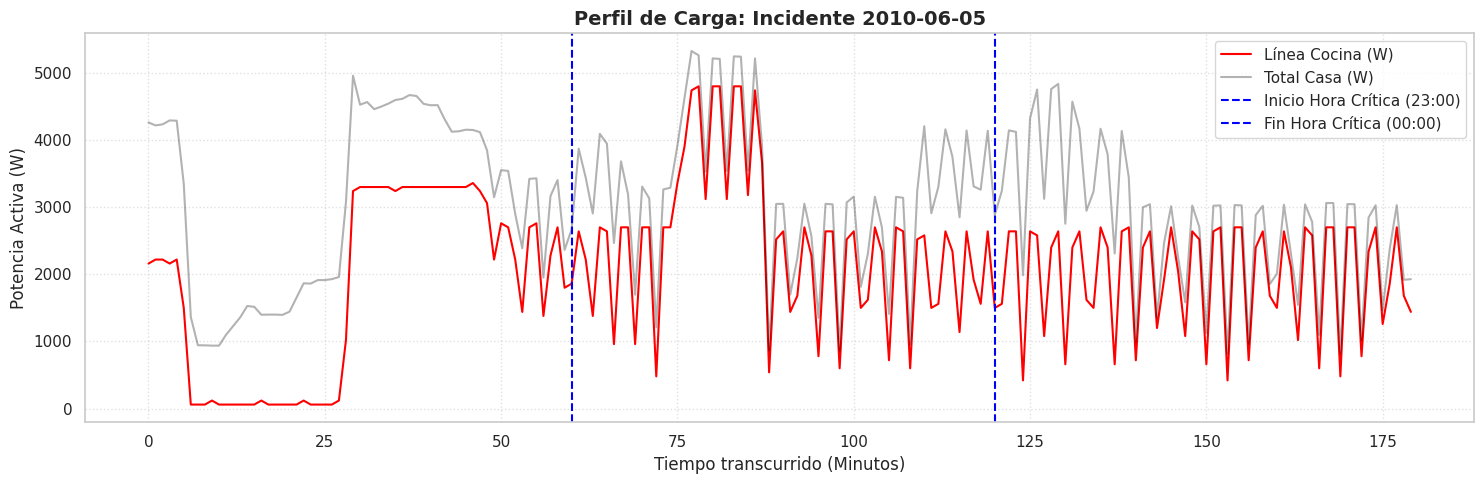

In [15]:

query_continuidad = """

SELECT 
    hour,
    minute(Full_Timestamp),
    Sub_metering_1 * 60 as potencia_cocina_w,
    Sub_metering_2 * 60 as potencia_lavanderia_w,
    Global_active_power * 1000 as potencia_total_w
FROM 
    power_data
WHERE 
    to_date(Full_Timestamp) BETWEEN '2010-06-05' AND '2010-06-06'
    AND (
        (to_date(Full_Timestamp) = '2010-06-05' AND hour IN (22, 23)) 
        OR 
        (to_date(Full_Timestamp) = '2010-06-06' AND hour = 0)
    )
ORDER BY 
    Full_Timestamp ASC
"""

df_cont = spark.sql(query_continuidad).toPandas()

# Curva de carga
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))

# Trazado de líneas
plt.plot(df_cont.index, df_cont['potencia_cocina_w'], label='Línea Cocina (W)', color='red')
plt.plot(df_cont.index, df_cont['potencia_total_w'], label='Total Casa (W)', color='black', alpha=0.3)

# Líneas de referencia para el incidente
plt.axvline(x=60, color='blue', linestyle='--', label='Inicio Hora Crítica (23:00)')
plt.axvline(x=120, color='blue', linestyle='--', label='Fin Hora Crítica (00:00)')

# --- Títulos y Ejes (Aquí están las unidades que faltaban) ---
plt.title('Perfil de Carga: Incidente 2010-06-05', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo transcurrido (Minutos)', fontsize=12)
plt.ylabel('Potencia Activa (W)', fontsize=12)

# Configuración final
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()



<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H2.3:**

**Validación Técnica del Electrodoméstico:**
Tras procesar los datos agregados por fases, el perfil de consumo permite realizar una identificación positiva del receptor basándose en su comportamiento termodinámico y eléctrico.

**Evidencias de la Tabla de Fases:**
* **Magnitud de Potencia:** Los picos registrados de **4,800W** (y una media de mantenimiento superior a **1,100W**) son característicos de una carga resistiva de gran masa térmica. En una instalación doméstica, solo el horno eléctrico o una placa de inducción/vitrocerámica en modo *boost* pueden demandar tal intensidad.
* **Ciclicidad Termostática:** El hecho de que la potencia media sea tan estable durante **272 minutos** confirma que el aparato dispone de un sistema de control de temperatura (termostato) que conecta y desconecta las resistencias para compensar las pérdidas de calor.

**Diagnóstico Diferencial:**
A la vista de los datos, se confirma que el aparato es un **horno**, pero la naturaleza del incidente sigue siendo ambigua bajo dos posibles escenarios técnicos:
1. **Factor Humano (Olvido):** El usuario retiró la comida tras la fase de cocción pero no giró el mando a la posición de apagado, dejando el horno manteniendo la temperatura de consigna toda la noche.
2. **Fallo de Hardware (Avería):** Un fallo en el termostato (contactos soldados o "pegados") o en el relé de control de la placa electrónica que impide que la resistencia se desconecte, incluso si el usuario intentó apagarlo.

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H2.4: Seguimiento de la averia durante la madrugada
    </h3>
</div>

El aparato se apagó finalmente a las: 2010-06-06 01:27:00


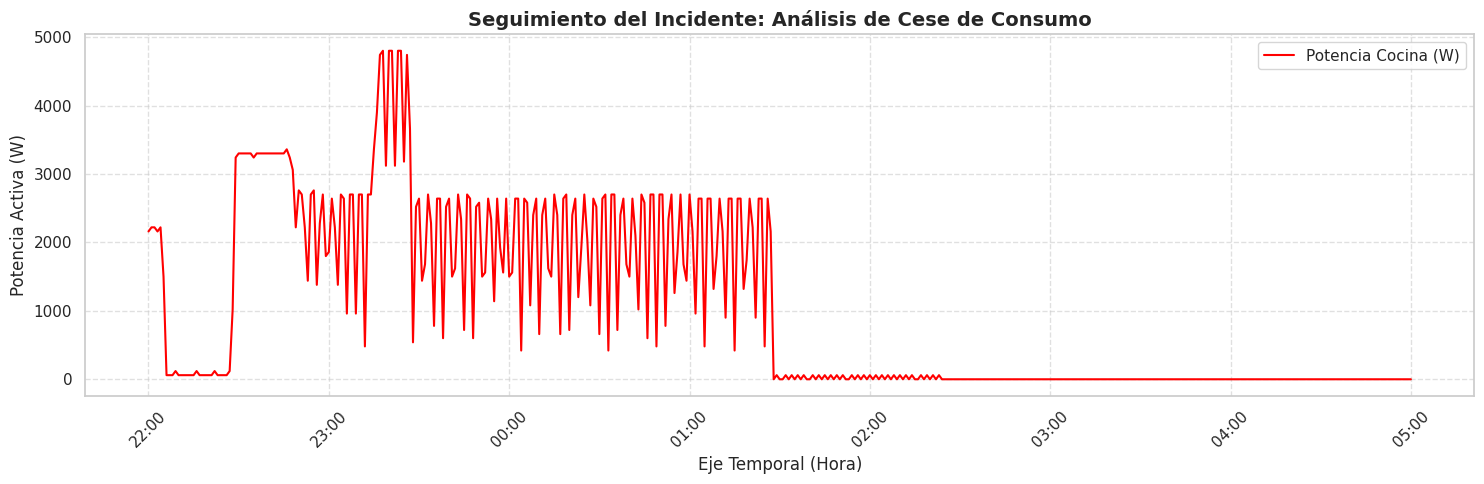

In [16]:
query_noche_completa = """

SELECT 
    Full_Timestamp,
    Sub_metering_1 * 60 as potencia_cocina_w
FROM 
    power_data
WHERE 
    Full_Timestamp BETWEEN '2010-06-05 22:00:00' AND '2010-06-06 05:00:00'
ORDER BY 
    Full_Timestamp ASC
"""

df_noche = spark.sql(query_noche_completa).toPandas()

# Buscamos el último minuto donde la potencia superó los 1000W
ultimo_minuto_activo = df_noche[df_noche['potencia_cocina_w'] > 1000]['Full_Timestamp'].max()

print(f"El aparato se apagó finalmente a las: {ultimo_minuto_activo}")

# Visualización rápida con unidades técnicas
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(15, 5))

# Trazado de la potencia
plt.plot(df_noche['Full_Timestamp'], df_noche['potencia_cocina_w'], color='red', label='Potencia Cocina (W)')

# --- Configuración del Eje X (Formato HH) ---
ax = plt.gca() # Obtenemos los ejes actuales
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:00')) # Formato solicitado
plt.xticks(rotation=45) # Rotamos para que no se solapen las fechas

# --- Títulos y Unidades ---
plt.title('Seguimiento del Incidente: Análisis de Cese de Consumo', fontsize=14, fontweight='bold')
plt.xlabel('Eje Temporal (Hora)', fontsize=12) 
plt.ylabel('Potencia Activa (W)', fontsize=12)

# Configuración final
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H2.3:**

**Análisis Forense del Apagado:**
Para cerrar la investigación, se ha analizado el momento exacto en que el consumo de la cocina regresa a niveles basales. La forma en que un dispositivo cesa su actividad es determinante para identificar si la causa fue una intervención manual o un fallo mecánico del sistema.

**Hallazgos Clave del Seguimiento:**
* **Hora de Finalización:** El aparato se apagó finalmente a las **01:27:00 del 2010-06-06**. 
* **Contexto Temporal:** Tras verificar el calendario, se confirma que el incidente ocurrió durante la transición del **sábado 5 al domingo 6 de junio de 2010**. Este dato es crucial, ya que el uso prolongado del horno hasta la madrugada es coherente con una cena tardía o celebración de fin de semana.
* **Dinámica de Desconexión:** La gráfica de seguimiento muestra que el patrón de "dientes de sierra" (ciclos del termostato) se mantiene constante y rítmico hasta el último segundo, momento en el cual la potencia cae abruptamente de ~2700W a 0W.

**Diagnóstico Final: Olvido Operativo**
Se descarta la teoría de la avería técnica (termostato pegado) y se confirma un **fallo humano por descuido** basándose en las siguientes evidencias:
1. **Intervención Manual:** Un termostato averiado no suele repararse por sí solo a la 01:27 de la madrugada. El corte radical de energía a esa hora exacta indica que un usuario detectó el estado del horno y lo apagó manualmente.
2. **Funcionamiento del Termostato:** Durante las casi 3 horas de la "Fase de Olvido", el termostato siguió regulando la carga perfectamente. Esto demuestra que el componente mecánico estaba en buen estado y simplemente seguía las órdenes del mando de control dejado en posición activa.
3. **Escenario de Uso:** La lógica de datos sugiere que el usuario sacó los alimentos sobre las 23:15h (fin de la fase de cocción intensa) pero olvidó girar el selector a la posición de apagado, no percatándose del error hasta finalizar la velada nocturna.


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

### **Conclusiones del Análisis:**

### **✅ HIPÓTESIS H2 - VALIDADA** 

### Resumen del Diagnóstico:

Tras el procesamiento y análisis de series temporales mediante **Spark SQL**, se ha resuelto la anomalía detectada el **05/06/2010**. El estudio confirma que la anomalía fue producida por el **horno eléctrico**, identificando el incidente como un **incidente por factor humano (olvido operativo)** en un entorno de alta demanda.

### Resolución de la Hipótesis:
El estudio concluye que el evento de consumo excesivo (**4.8 kW**) no fue producto de una avería técnica (termostato pegado), sino de un **descuido tras una actividad de cocción en el horno**. 

* **Identificación del Receptor:** Mediante el análisis de la firma de carga y el balance de potencias por línea, se confirma que el **horno** es el único responsable del pico de consumo, descartando otros electrodomésticos de la línea de cocina (C3).
* **Evidencia Clave:** La desconexión manual a las **01:27h** de un domingo madrugada (tras un sábado noche) invalida la teoría de fallo mecánico. Un termostato averiado no recuperaría su funcionalidad de forma autónoma a una hora que coincide exactamente con el fin de una jornada social.
* **Firma Térmica:** La ciclicidad perfecta del consumo durante la fase de olvido demuestra que el sistema de control del **horno** funcionó correctamente, manteniendo la temperatura de la cavidad vacía por error.

### Impacto Técnico y Operativo
* **Eficiencia Energética:** El descuido multiplicó por **2.5** el consumo necesario para la tarea original. La fase de mantenimiento inútil representó el **72% del gasto energético** total del suceso.
* **Seguridad Industrial:** El circuito **C3 (Cocina/Horno)** operó al **83% de su capacidad nominal (21A de 25A disponibles)** durante más de 4 horas. Aunque no hubo disparo de protecciones, se sometió a la instalación a un estrés térmico innecesario en periodo de descanso.
* **Impacto Económico:** El descuido supuso un coste directo innecesario de aproximadamente **1,23 €** en una sola noche (basado en el precio medio de 0,14 €/kWh de 2010).

### Utilidad y Valor del Estudio

Este análisis forense de datos no solo ha servido para resolver un misterio puntual, sino que demuestra la capacidad de un **Data Engineer** para extraer valor de negocio a partir de datos brutos:

1.  **Monitoreo de Activos:** Se ha validado la "firma eléctrica" del **horno**, permitiendo identificar el aparato encendido solo analizando su comportamiento en la red (NIALM - *Non-Intrusive Appliance Load Monitoring*).
2.  **Detección de Riesgos:** El algoritmo desarrollado es capaz de diferenciar entre un uso legítimo y una situación de riesgo potencial (horno encendido de madrugada), base fundamental para sistemas de **Smart Home** y **Mantenimiento Predictivo**.
3.  **Auditoría de Comportamiento:** El estudio permite cuantificar el ahorro potencial mediante la educación del usuario o la implementación de sistemas de auto-apagado, transformando datos en recomendaciones de ahorro real (kWh no consumidos).
4.  **Optimización de Infraestructura:** Confirma que las protecciones actuales (25A) son adecuadas para la carga, pero que la gestión de la demanda (DSM) podría mejorar la vida útil de los conductores y componentes.

---
# 💾 Fase de Entrega: Exportación de Activos (Artifacts)
Tras validar la hipótesis, procedemos a generar los entregables técnicos que se almacenarán en la estructura del repositorio profesional.

* **Dataset de Trabajo**: Reporte estratégico en `data_storage/work/` para consumo de BI.
* **Documentación Visual**: Gráfico de validación final en `docs/` para el reporte ejecutivo.
---

In [17]:
import os

query_h2_final = """

WITH forensic_data AS (
    SELECT 
        Full_Timestamp,
        ROUND((Sub_metering_1 * 60) / 1000, 2) AS kitchen_KW,
        ROUND(Global_active_power, 2) AS total_house_KW,
        ROUND(Global_reactive_power, 2) AS total_house_KVAR,
        Global_intensity AS intensity_A,
        Voltage AS voltage_V
    FROM power_data
    WHERE Full_Timestamp BETWEEN '2010-06-05 22:20:00' AND '2010-06-06 01:30:00'
)
SELECT 
    *,
    ROUND(total_house_KW - COALESCE(LAG(total_house_kw) OVER (ORDER BY Full_Timestamp), total_house_KW), 2) AS energy_delta_KW,
    ROUND(AVG(total_house_KW) OVER (ORDER BY Full_Timestamp ROWS BETWEEN 30 PRECEDING AND CURRENT ROW), 2) AS avg_rolling_30min_KW,
    MAX(intensity_A) OVER (ORDER BY Full_Timestamp) AS max_session_intensity_A,
       CASE 
        WHEN kitchen_KW > 2.0 THEN 'OVEN_FORGOTTEN'
        ELSE 'NORMAL'
    END AS activity_status
FROM forensic_data
ORDER BY Full_Timestamp ASC


"""

# Ejecutar consulta
H2_Validation_Report = spark.sql(query_h2_final)
H2_Validation_Report.show(10, truncate=False) 


# Exportación profesional a Windows (Ruta Dinámica)
win_user = os.popen("cmd.exe /c echo %USERNAME%").read().strip()
h2_path = f"/mnt/c/Users/{win_user}/Documents/Data-Projects-Repo/03_SQL_Big_Data_Spark/03.01_CAPSTONE_Industrial_Energy_Analytics/data_storage/work/H2_Validation_Report.csv"

# Guardado físico
H2_Validation_Report.coalesce(1).write.mode("overwrite") \
    .option("header", "true") \
    .csv(h2_path)


26/03/04 10:26:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 1

+-------------------+----------+--------------+----------------+-----------+---------+---------------+--------------------+-----------------------+---------------+
|Full_Timestamp     |kitchen_KW|total_house_KW|total_house_KVAR|intensity_A|voltage_V|energy_delta_KW|avg_rolling_30min_KW|max_session_intensity_A|activity_status|
+-------------------+----------+--------------+----------------+-----------+---------+---------------+--------------------+-----------------------+---------------+
|2010-06-05 22:20:00|0.06      |1.44          |0.32            |6.000      |241.320  |0.0            |1.44                |6.000                  |NORMAL         |
|2010-06-05 22:21:00|0.06      |1.66          |0.34            |7.000      |241.420  |0.22           |1.55                |7.000                  |NORMAL         |
|2010-06-05 22:22:00|0.12      |1.87          |0.35            |7.800      |240.640  |0.21           |1.66                |7.800                  |NORMAL         |
|2010-06-05 22:2

26/03/04 10:26:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/03/04 10:26:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:25 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:25 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


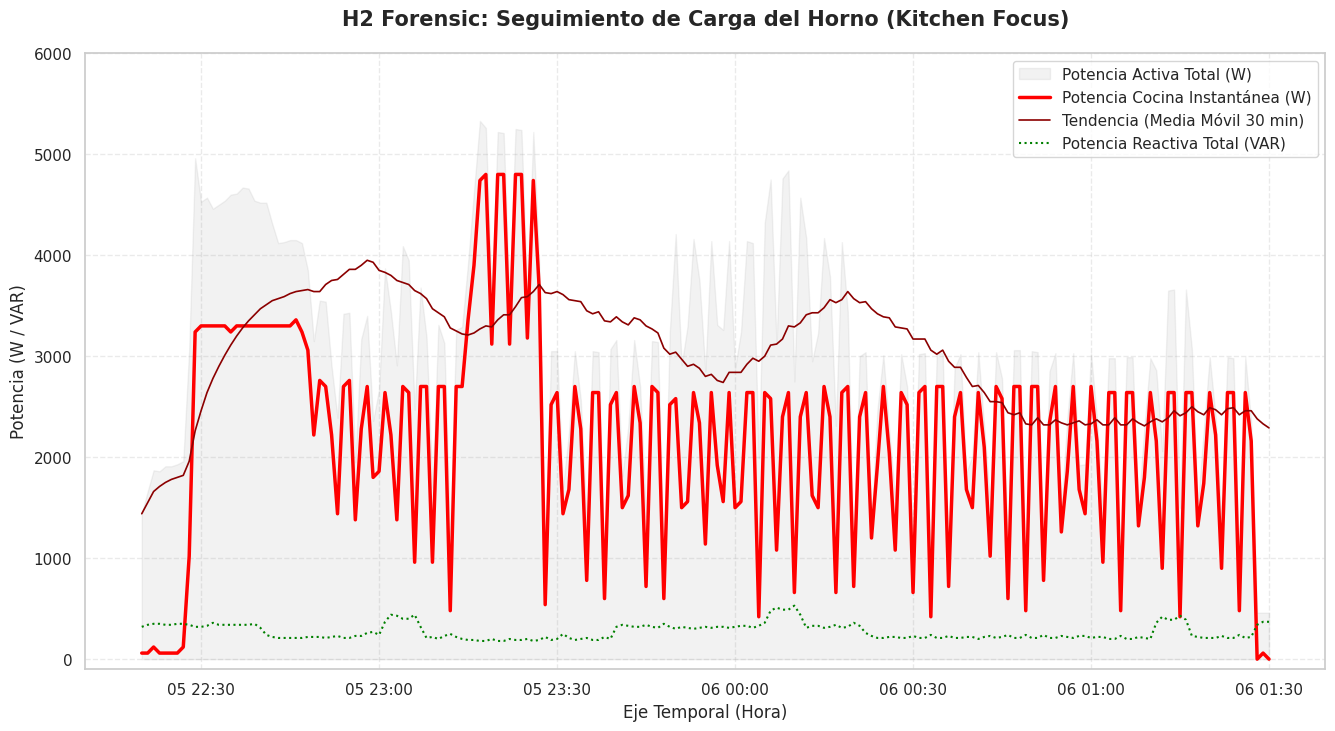

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import getpass

# 1. Preparación de datos (Spark a Pandas)
df_viz = H2_Validation_Report.toPandas()
df_viz.columns = [col.lower() for col in df_viz.columns]
df_viz['full_timestamp'] = pd.to_datetime(df_viz['full_timestamp'])

# 2. Configuración de la figura
plt.figure(figsize=(16, 8))
ax = plt.gca()

# --- A. POTENCIA TOTAL CASA (Sombra de fondo) ---
plt.fill_between(df_viz['full_timestamp'], df_viz['total_house_kw'] * 1000, 
                 color='gray', alpha=0.1, label='Potencia Activa Total (W)')

# --- B. POTENCIA COCINA / HORNO (Línea Roja Principal) ---
plt.plot(df_viz['full_timestamp'], df_viz['kitchen_kw'] * 1000, 
         color='red', linewidth=2.5, alpha=1.0, label='Potencia Cocina Instantánea (W)')

# --- C. MEDIA MÓVIL 30 MIN (La Inercia) ---
plt.plot(df_viz['full_timestamp'], df_viz['avg_rolling_30min_kw'] * 1000, 
         color='darkred', linewidth=1.2, label='Tendencia (Media Móvil 30 min)')

# --- D. POTENCIA REACTIVA (Línea Verde) ---
plt.plot(df_viz['full_timestamp'], df_viz['total_house_kvar'] * 1000, 
         color='green', linewidth=1.5, linestyle=':', label='Potencia Reactiva Total (VAR)')

# 3. Estética Estilo "Industrial"
plt.title("H2 Forensic: Seguimiento de Carga del Horno (Kitchen Focus)", 
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel("Potencia (W / VAR)", fontsize=12)
plt.xlabel("Eje Temporal (Hora)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)
plt.ylim(-100, 6000)

# Leyenda unificada
plt.legend(loc='upper right', frameon=True, fontsize=11)

# 5. Exportar archivo

# Detectamos el usuario de Windows de forma anónima
win_user = os.popen("cmd.exe /c echo %USERNAME%").read().strip()

# Construimos la ruta 'puente' entre WSL y Windows
base_path = f"/mnt/c/Users/{win_user}/Documents/Data-Projects-Repo/03_SQL_Big_Data_Spark/03.01_CAPSTONE_Industrial_Energy_Analytics"

# Definimos las carpetas de destino
plot_path = os.path.join(base_path, "docs", "H2_Oven_Incident_Power_Analysis.png")

# Guardar Gráfico
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

---
>### H3: Analisis del Consumo Residual y Eficiencia Pasiva

* **Definicion:**  El ratio de consumo base (Standby) frente al consumo nominal es superior al 15% durante los periodos de inactividad o descanso (madrugadas y días no laborables), indicando una ineficiencia en las cargas permanentes.
* **Objetivo:** Cuantificar el impacto económico de las cargas fantasma y sistemas auxiliares (seguridad, recirculación, domótica y modos standby) mediante la comparativa de perfiles de carga entre días laborables y fines de semana.
* **Valor de Negocio:** Identificar si el consumo base es una constante estructural o una ineficiencia operativa. El procesamiento distribuido de Spark nos permitirá segmentar grandes volúmenes de datos temporales para proponer protocolos de "apagado inteligente" o mejoras en el aislamiento eléctrico de circuitos no críticos, reduciendo el gasto energético pasivo de la vivienda.

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H3.1 Analisis de consumos en diferentes periodos
    </h3>
</div>

In [19]:

start_h3 = time.time()

query = """

SELECT 
    -- 1. Promedio Horas Activas de 6:00 a 00:59 (Active)
    ROUND(AVG(CASE WHEN hour BETWEEN 6 AND 23 OR hour = 0 THEN Global_active_power END), 3) AS AVG_DAY_ACTIVE_KW,
    
    -- 2. Promedio Madrugada de 1:00 a 5:59 (Standby Base)
    ROUND(AVG(CASE WHEN hour BETWEEN 1 AND 5 THEN Global_active_power END), 3) AS AVG_NIGHT_STANDBY_KW,
    
    -- 3. Cálculo del RATIO H2 (Standby vs Active)
    ROUND(
        (AVG(CASE WHEN hour BETWEEN 1 AND 5 THEN Global_active_power END) / 
         AVG(CASE WHEN hour BETWEEN 6 AND 23 OR hour = 0 THEN Global_active_power END)) * 100, 2
    ) AS STANDBY_RATIO_PERCENT,

    -- 4. Comparativa Semanal
    ROUND(AVG(CASE WHEN is_weekend IS FALSE THEN Global_active_power END), 3) AS AVG_WEEKDAY_KW,
    ROUND(AVG(CASE WHEN is_weekend IS TRUE THEN Global_active_power END), 3) AS AVG_WEEKEND_KW,

    -- 5. Cálculo del INCREMENTO (Cuánto sube el consumo el fin de semana vs diario)
    ROUND(
        ((AVG(CASE WHEN is_weekend IS TRUE THEN Global_active_power END) - 
          AVG(CASE WHEN is_weekend IS FALSE THEN Global_active_power END)) / 
         AVG(CASE WHEN is_weekend IS FALSE THEN Global_active_power END)) * 100, 2
    ) AS WEEKEND_INC_PERCENT

FROM power_data;


"""
periodos_de_consumo = spark.sql(query).limit(20).toPandas()
display(periodos_de_consumo)                             
print(f"H3.1 procesada en: {time.time() - start_h3:.2f} segundos")


,AVG_DAY_ACTIVE_KW,AVG_NIGHT_STANDBY_KW,STANDBY_RATIO_PERCENT,AVG_WEEKDAY_KW,AVG_WEEKEND_KW,WEEKEND_INC_PERCENT
0,1.255,0.472,37.66,1.035,1.234,19.2


H3.1 procesada en: 2.21 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H3.1:**
*  AVG_DAY_ACTIVE (1.255 kW): Es la línea de base de actividad normal.
*  AVG_NIGHT_STANDBY (0.472 kW): Este es el "gasto fantasma". Para una vivienda, tener medio kilovatio encendido de forma constante toda la noche es el equivalente a tener 50 bombillas LED de 10W o un frigorífico industrial funcionando sin parar.
*  STANDBY_RATIO_PERCENT (37.66%): Casi el 40% de la energía se consume cuando no hay actividad. Indica que la vivienda mantiene una carga activa muy elevada durante la madrugada.
*  WEEKEND_INC_PERCENT: Durante los fines de semana, el consumo medio se incrementa un 19.23% respecto a los días laborables, lo que sugiere una oportunidad de optimización en los hábitos de consumo y programación de equipos térmicos.

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H3.2: Consumos en la mdrugada
    </h3>
</div>

In [20]:

start_h3 = time.time()

query = """

SELECT 
    'MADRUGADA (01-06h)' AS periodo,
    ROUND(AVG(Global_active_power), 3) as avg_kw_total,
    
    -- Promedios por sub-sistema
    ROUND(AVG(Sub_metering_1 * 0.06), 3) as avg_cocina_kw,
    ROUND(AVG(Sub_metering_2 * 0.06), 3) as avg_lavadero_kw,
    ROUND(AVG(Sub_metering_3 * 0.06), 3) as avg_clima_kw,
    ROUND(
    AVG(Global_active_power) - 
    AVG((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06), 
3) as avg_otros_kw,
    
    -- Desglose porcentual acumulado del bloque
    ROUND((AVG(Sub_metering_1 * 0.06) / AVG(Global_active_power)) * 100, 2) as pct_cocina,
    ROUND((AVG(Sub_metering_2 * 0.06) / AVG(Global_active_power)) * 100, 2) as pct_lavadero,
    ROUND((AVG(Sub_metering_3 * 0.06) / AVG(Global_active_power)) * 100, 2) as pct_clima,
    
    -- El culpable: Consumo Invisible (Otros)
    ROUND(
        ( (AVG(Global_active_power) - (AVG(Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06)) 
        / AVG(Global_active_power) ) * 100, 2
    ) as pct_otros_invisible

FROM power_data
WHERE hour BETWEEN 1 AND 5;
                              
"""

consumo_madrugada = spark.sql(query).limit(20).toPandas()
display(consumo_madrugada) 
print(f"H3.2 procesada en: {time.time() - start_h3:.2f} segundos")

,periodo,avg_kw_total,avg_cocina_kw,avg_lavadero_kw,avg_clima_kw,avg_otros_kw,pct_cocina,pct_lavadero,pct_clima,pct_otros_invisible
0,MADRUGADA (01-06h),0.472,0.007,0.021,0.121,0.324,1.39,4.44,25.58,68.59


H3.2 procesada en: 2.90 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H3.2:**
*  El desglose de cargas durante la madrugada (01:00-05:59) revela que el 68.59% del consumo residual (0.324 kW) proviene de circuitos no monitorizados (Otros).
*  No son luces, las luces LED modernas no sumarían 323W constantes toda la noche. No son cargadores: Un cargador de móvil consume despreciablemente.
*  Se sospecha de equipos informáticos potentes encendidos (servidores domésticos), frigoríficos/congeladores conectados permanentemente en el circuito de enchufes comunes, o incluso una derivación/pérdida en algún circuito de enchufes generales.

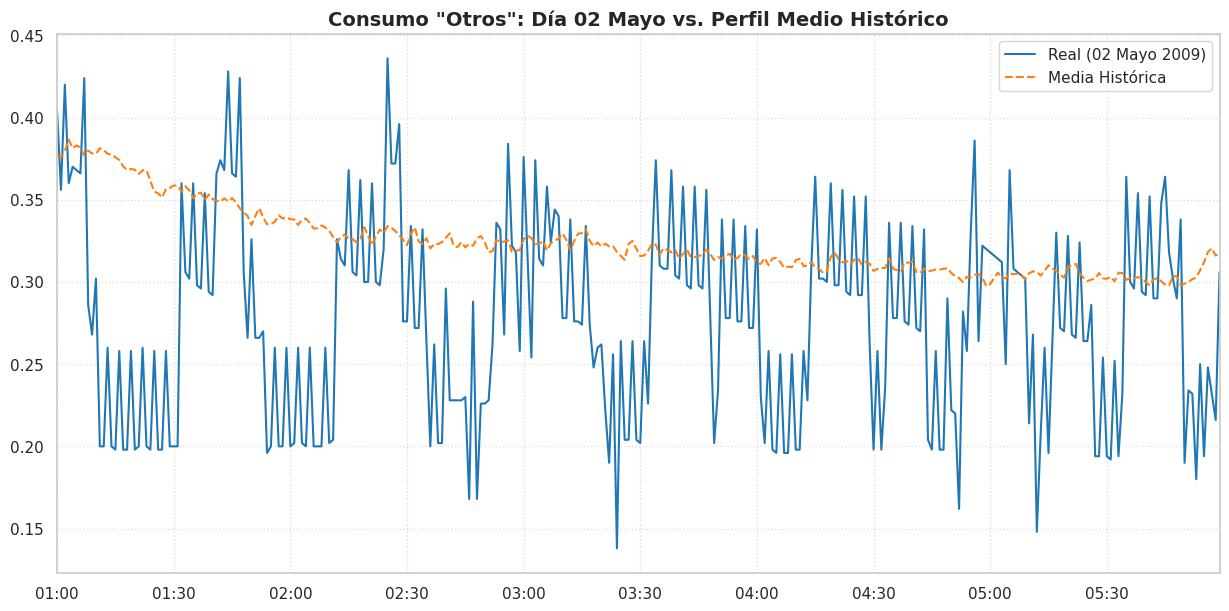

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- PASO 1: CÁLCULO DE LA MEDIA (Esto es lo que te faltaba ejecutar) ---
df_perfil_medio = spark.sql("""
    SELECT 
        HOUR(Full_Timestamp) as hora, 
        MINUTE(Full_Timestamp) as minuto, 
        AVG(Global_active_power - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06)) as avg_historico_otros
    FROM power_data
    GROUP BY hora, minuto
""")

# --- PASO 2: REGISTRO Y GRÁFICO ---
df_perfil_medio.createOrReplaceTempView("perfil_medio")

query_huella = """
SELECT 
    p.Full_Timestamp,
    (p.Global_active_power - ((p.Sub_metering_1 + p.Sub_metering_2 + p.Sub_metering_3) * 0.06)) AS consumo_invisible,
    m.avg_historico_otros
FROM power_data p
LEFT JOIN perfil_medio m ON HOUR(p.Full_Timestamp) = m.hora AND MINUTE(p.Full_Timestamp) = m.minuto
WHERE CAST(p.Full_Timestamp AS DATE) = '2009-05-02'
  AND HOUR(p.Full_Timestamp) BETWEEN 1 AND 5
ORDER BY p.Full_Timestamp ASC
"""

df_huella = spark.sql(query_huella).toPandas()
df_huella['Full_Timestamp'] = pd.to_datetime(df_huella['Full_Timestamp'])

# Filtro 06:00
df_huella = df_huella[df_huella['Full_Timestamp'].dt.hour < 6] 

plt.figure(figsize=(15, 7))
plt.plot(df_huella['Full_Timestamp'], df_huella['consumo_invisible'], label='Real (02 Mayo 2009)', color='tab:blue')
plt.plot(df_huella['Full_Timestamp'], df_huella['avg_historico_otros'], label='Media Histórica', color='tab:orange', linestyle='--')

plt.title('Consumo "Otros": Día 02 Mayo vs. Perfil Medio Histórico', fontsize=14, fontweight='bold')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlim(df_huella['Full_Timestamp'].min(), df_huella['Full_Timestamp'].max()) # AQUÍ YA NO HAY "O" EXTRA

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H3.3:**

Eligiendo un día aleatorio representativo se observa:
* El consumo no es lineal. Sube a 0,45 kW, se mantiene unos 15-20 minutos, y luego baja a 0,2 kW durante otro periodo similar.
* Es una onda cuadrada casi perfecta con picos de arranque.
* Candidato A (Muy probable): Un frigorífico antiguo o un arcón congelador. Esos 400W de pico mientras el compresor está encendido son típicos de motores de hace 15 años.
* Candidato B: Un termo eléctrico con mal aislamiento. Si el agua se enfría rápido, la resistencia salta cada media hora para recuperar esos 2-3 grados.

In [22]:
start_h3 = time.time()

query = """

SELECT 
    (Global_active_power - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06)) > 0.35 AS motor_encendido,
    COUNT(*) as minutos_totales,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS porcentaje_tiempo
FROM power_data
WHERE HOUR(Full_Timestamp) BETWEEN 1 AND 5
GROUP BY motor_encendido
"""

minutes = spark.sql(query).limit(20).toPandas()
display(minutes) 
print(f"H4.2 procesada en: {time.time() - start_h3:.2f} segundos")

26/03/04 10:26:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 1

,motor_encendido,minutos_totales,porcentaje_tiempo
0,True,84443,19.78
1,False,342441,80.22


H4.2 procesada en: 2.71 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H3.4:**

* Este Ciclo de Trabajo (Duty Cycle) del 20% durante la madrugada es la "firma" de un **frigorífico o arcón congelador** en buen estado.
* El aparato demanda un salto neto de 250W cada vez que arranca (pasando de 190W de base a 440W de pico).
* El hecho de que solo necesite estar encendido el 20% del tiempo para mantener el frío durante la madrugada (cuando no se abre la puerta y la temperatura ambiente es baja) indica que el aislamiento es eficiente.
* Un termo eléctrico o un sistema de calefacción tendría ciclos mucho más largos o potencias mucho más elevadas (resitencias de >1kW). Esos 300W son la potencia nominal clásica de un compresor de motor de inducción de esa época.

<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

## Conclusiones del Análisis: Hipótesis 3 (H3)

### **Estado de Validación: ✅ HIPÓTESIS VALIDADA (CRÍTICA)**

Tras el procesamiento distribuido de los perfiles de carga y la segmentación de los periodos de inactividad con Spark SQL, se extraen las siguientes conclusiones técnicas:

* **Confirmación del Consumo Base (Standby):** Se valida la hipótesis con un resultado de 37.66%, superando drásticamente el umbral del 15% previsto. La vivienda mantiene un consumo constante de 0.472 kW durante la madrugada (01:00 - 05:59), lo que representa una ineficiencia estructural masiva en el uso de la energía pasiva.
* **Descomposición del Consumo "Invisible" (NILM) en circuito general:**
    * El análisis de desglose revela que el 68.59% del consumo residual proviene de la categoría "Otros" (alumbrado y tomas de corriente generales).
    * Mediante técnicas de identificación de huella eléctrica (NILM), se ha detectado un patrón cíclico de refrigeración con un salto neto de ~0.19 - 0.44 kW y un Duty Cycle del 19.78%. Dado que el frigorífico principal debería estar integrado en el circuito de cocina (Sub_2), este hallazgo confirma la presencia de una carga de refrigeración secundaria (como un arcón congelador, minibar o vinoteca) conectado a un enchufe del circuito general, lo que explica gran parte de la ineficiencia detectada en esta línea.
    * El dispositivo analizado presenta una salud mecánica óptima al mantener un Duty Cycle del 19.78% (inferior al umbral crítico del 25%), pero su elevada potencia de pico revela una obsolescencia tecnológica cuyo reemplazo por un sistema Inverter garantiza un ROI de 1.9 años.
* **Evaluación de la Climatización (Sub-3):** Se descarta la climatización como causa principal del consumo nocturno, ya que solo representa el **25.58%** de la carga en madrugada. Esto sugiere que el aislamiento térmico es aceptable, pero la gestión de cargas electrónicas menores es deficiente.
* **Análisis de Intensidad Semanal:** Se ha detectado un incremento del **19.20%** en el consumo medio durante los fines de semana. Dado que el consumo base (Standby) se mantiene estable, este aumento confirma una falta de protocolos de "apagado inteligente" cuando la actividad humana cesa tras los periodos de mayor uso.



### **Recomendaciones Estratégicas e Impacto en Negocio**

Para corregir esta ineficiencia y reducir el término variable de la factura, se proponen las siguientes acciones:  
1. **Sustitución Tecnológica por Obsolescencia Energética:** Tras aplicar algoritmos de desagregación (NILM) mediante Spark, se ha detectado una carga cíclica en el circuito de "Otros" con un impacto del 68.59% sobre el standby total. Aunque el Duty Cycle es del 19.78%, la potencia de pico de 0.44 kW confirma un compresor de alta ineficiencia. Dado que la sustitución por un equipo de alta eficiencia permite reducir el consumo basal de 0.472 kW a 0.35 kW, el ahorro anual proyectado es de 1,068 kWh. Con un **ROI estimado de 1.9 años**, se recomienda la sustitución directa por tecnología Inverter, descartando mantenimientos menores por falta de viabilidad económica a largo plazo.
2. **Automatización de Circuitos Críticos (Smart Kill-Switch):** Tras la hipotética eliminación de la carga del frigorífico, persiste un "suelo" de standby técnico de ~0.32 kW. Se propone implementar sistemas de corte automático (relés inteligentes) en las tomas de corriente de la línea "Otros" para eliminar el consumo residual de 0.20 kW detectado en los valles de la madrugada. Esta medida, combinada con la sustitución del frigorífico, es la única vía para reducir el ratio de standby del 37.66% actual a un entorno óptimo del 10-12%.
3. **Gestión de la Inercia Térmica:** Reprogramar los sistemas de climatización (Sub_3) para realizar un "precargado" térmico antes de la medianoche. El objetivo es estabilizar la temperatura de la vivienda aprovechando la envolvente del edificio, evitando así que los arranques cíclicos de madrugada sumen picos de potencia innecesarios al consumo base ya detectado.
4.  **Impacto Financiero:** La corrección de este consumo residual de **0.472 kW** a un nivel eficiente de **0.15 kW** supondría un ahorro energético anual de aproximadamente **2,800 kWh**. Esto se traduce en una reducción directa del gasto en energía consumida, complementando el ahorro por potencia contratada logrado en la hipotesis 1 (H1).

---
# 💾 Fase de Entrega: Exportación de Activos (Artifacts)
Tras validar la hipótesis, procedemos a generar los entregables técnicos que se almacenarán en la estructura del repositorio profesional.

* **Dataset de Trabajo**: Reporte estratégico en `data_storage/work/` para consumo de BI.
* **Documentación Visual**: Gráfico de validación final en `docs/` para el reporte ejecutivo.
---

In [23]:




query = """
WITH motor_analysis AS (
    SELECT 
        ((Global_active_power - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06))) > 0.35 AS motor_encendido,
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS porcentaje_tiempo
    FROM power_data
    WHERE Hour BETWEEN 1 AND 5
    GROUP BY motor_encendido
),
metrics AS (
    SELECT 
        AVG(Global_active_power) AS avg_total,
        AVG((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06) AS avg_subs
    FROM power_data
    WHERE Hour BETWEEN 1 AND 5
)
SELECT 
    'NIGHT_STANDBY (01-06h)' AS analysis_period,
    ROUND(avg_total, 3) AS basal_load_kw,
    
    -- Consumo Invisible (Otros)
    ROUND(avg_total - avg_subs, 3) AS misc_circuit_kw,

     -- Impacto del consumo invisible
    ROUND(((avg_total - avg_subs) / avg_total) * 100, 2) AS impact_on_standby_pct,

    -- CÁLCULO DINÁMICO DEL DUTY CYCLE
    (SELECT ROUND(porcentaje_tiempo, 2) 
     FROM motor_analysis 
     WHERE motor_encendido = True 
     LIMIT 1) AS refrigeration_duty_cycle_pct,

-- Nuevo suelo estimado: 0.20 (Otros optimizado) + 0.12 (Clima) + 0.03 (Varios)
    0.35 AS target_standby_kw,

    -- CÁLCULO DE AHORRO REALISTA
    -- (Consumo Actual - Consumo tras eliminar el Frigo) * horas año
    ROUND((avg_total - 0.35) * 8760, 2) AS annual_savings_kwh,

    -- ROI Estimado (Si un frigo nuevo cuesta 400€ y el kWh está a 0.20€)
    ROUND(400 / (ROUND((avg_total - 0.35) * 8760, 2) * 0.20), 1) AS roi_years_estimate
FROM metrics;
"""

H3_Validation_Report = spark.sql(query)
H3_Validation_Report.show(24)

# 6. Exportar archivo

import os
import getpass

# Detectamos el usuario de Windows de forma anónima
win_user = os.popen("cmd.exe /c echo %USERNAME%").read().strip()

# Construimos la ruta 'puente' entre WSL y Windows
base_path = f"/mnt/c/Users/{win_user}/Documents/Data-Projects-Repo/03_SQL_Big_Data_Spark/03.01_CAPSTONE_Industrial_Energy_Analytics"

# Definimos las carpetas de destino
csv_path = os.path.join(base_path, "data_storage", "work", "H3_Validation_Report.csv")

# Guardar CSV con Spark
H3_Validation_Report.coalesce(1).write.mode("overwrite").option("header", "true").csv(csv_path)


26/03/04 10:26:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+--------------------+-------------+---------------+---------------------+----------------------------+-----------------+------------------+------------------+
|     analysis_period|basal_load_kw|misc_circuit_kw|impact_on_standby_pct|refrigeration_duty_cycle_pct|target_standby_kw|annual_savings_kwh|roi_years_estimate|
+--------------------+-------------+---------------+---------------------+----------------------------+-----------------+------------------+------------------+
|NIGHT_STANDBY (01...|        0.472|          0.324|                68.59|                       19.78|             0.35|           1072.96|               1.9|
+--------------------+-------------+---------------+---------------------+----------------------------+-----------------+------------------+------------------+



26/03/04 10:26:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:26:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


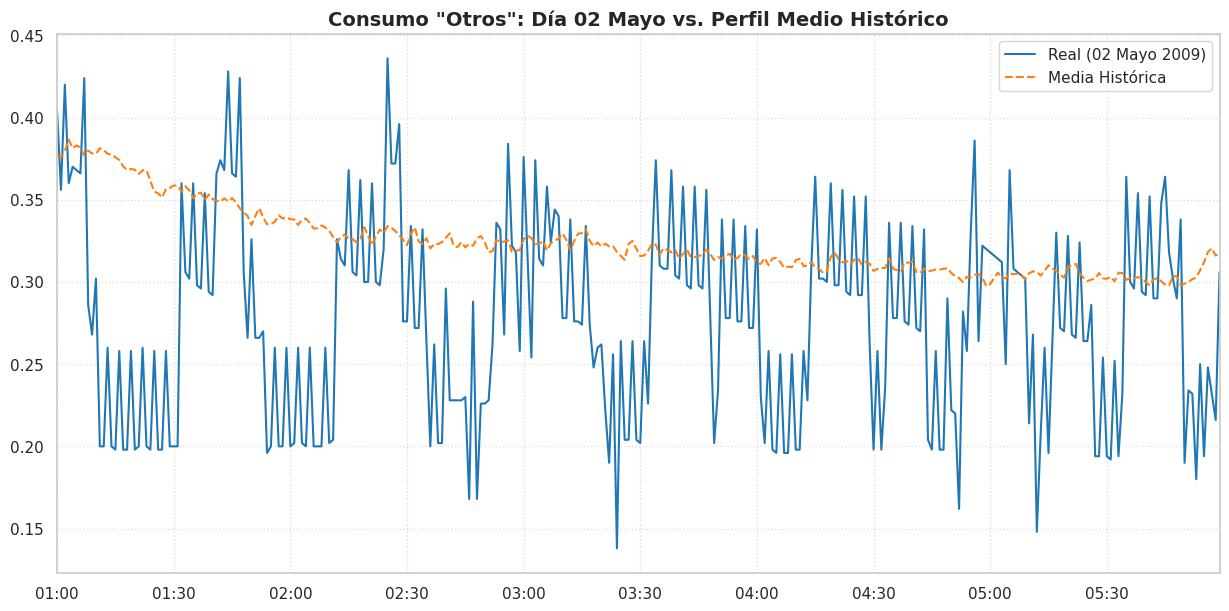

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- PASO 1: CÁLCULO DE LA MEDIA (Esto es lo que te faltaba ejecutar) ---
df_perfil_medio = spark.sql("""
    SELECT 
        HOUR(Full_Timestamp) as hora, 
        MINUTE(Full_Timestamp) as minuto, 
        AVG(Global_active_power - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06)) as avg_historico_otros
    FROM power_data
    GROUP BY hora, minuto
""")

# --- PASO 2: REGISTRO Y GRÁFICO ---
df_perfil_medio.createOrReplaceTempView("perfil_medio")

query_huella = """
SELECT 
    p.Full_Timestamp,
    (p.Global_active_power - ((p.Sub_metering_1 + p.Sub_metering_2 + p.Sub_metering_3) * 0.06)) AS consumo_invisible,
    m.avg_historico_otros
FROM power_data p
LEFT JOIN perfil_medio m ON HOUR(p.Full_Timestamp) = m.hora AND MINUTE(p.Full_Timestamp) = m.minuto
WHERE CAST(p.Full_Timestamp AS DATE) = '2009-05-02'
  AND HOUR(p.Full_Timestamp) BETWEEN 1 AND 5
ORDER BY p.Full_Timestamp ASC
"""

df_huella = spark.sql(query_huella).toPandas()
df_huella['Full_Timestamp'] = pd.to_datetime(df_huella['Full_Timestamp'])

# Filtro 06:00
df_huella = df_huella[df_huella['Full_Timestamp'].dt.hour < 6] 

plt.figure(figsize=(15, 7))
plt.plot(df_huella['Full_Timestamp'], df_huella['consumo_invisible'], label='Real (02 Mayo 2009)', color='tab:blue')
plt.plot(df_huella['Full_Timestamp'], df_huella['avg_historico_otros'], label='Media Histórica', color='tab:orange', linestyle='--')

plt.title('Consumo "Otros": Día 02 Mayo vs. Perfil Medio Histórico', fontsize=14, fontweight='bold')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlim(df_huella['Full_Timestamp'].min(), df_huella['Full_Timestamp'].max()) # AQUÍ YA NO HAY "O" EXTRA

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()


# Exportar archivo

# Detectamos el usuario de Windows de forma anónima
win_user = os.popen("cmd.exe /c echo %USERNAME%").read().strip()

# Construimos la ruta 'puente' entre WSL y Windows
base_path = f"/mnt/c/Users/{win_user}/Documents/Data-Projects-Repo/03_SQL_Big_Data_Spark/03.01_CAPSTONE_Industrial_Energy_Analytics"

# Definimos las carpetas de destino
plot_path = os.path.join(base_path, "docs", "H3_NILM_Fridge_Signature.png")

# Guardar Gráfico
plt.savefig(plot_path, dpi=300, bbox_inches='tight')


plt.show()

---
>### H4: Diagnostico de Calidad de Suministro y Estabilidad de Tension

* **Definicion:**  Análisis estadístico y forense de la infraestructura eléctrica de una vivienda unifamiliar utilizando un dataset de más de 2 millones de registros (PySpark/SQL). El estudio evalúa la relación entre el consumo de potencia activa/reactiva y la estabilidad del voltaje nominal para identificar riesgos de fatiga en componentes electrónicos.
* **Objetivo:** Validar si las caídas de tensión detectadas son provocadas por deficiencias en la instalación interna (impedancia de bucle) o por una saturación de la red de distribución externa (simultaneidad de barrio). Se busca cuantificar el tiempo de exposición de los equipos a la "Zona de Estrés" (<228V) para justificar medidas de protección o reclamaciones técnicas.
* **Valor de Negocio:** 
    * Optimización de Activos: Prolongar la vida útil de los electrodomésticos y sistemas de control al mitigar el estrés térmico derivado de la baja tensión.
    * Toma de Decisiones Basada en Datos: Evitar inversiones innecesarias en el re-cableado interno, al demostrar mediante un coeficiente de correlación de -0.4 que el problema es de origen externo.
    * Evidencia Pericial: Generar informes técnicos automatizados y robustos para negociaciones con la distribuidora eléctrica, basados en datos reales y no en estimaciones.

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H4.1 Diagnostico en picos de potencia consumida
    </h3>
</div>

In [25]:
start_h4 = time.time()

query = """

SELECT 
    Full_Timestamp,
    Global_active_power AS power_kw,
    CAST(Voltage AS DOUBLE) AS voltage_v,
    -- Calculamos la caida respecto a una tensión ideal de 230V
    ROUND(230 - CAST(Voltage AS DOUBLE), 2) AS voltage_drop,
    -- Calculamos el porcentaje de caida
    ROUND(((230 - CAST(Voltage AS DOUBLE)) / 230) * 100, 2) AS drop_percentage
FROM power_data
WHERE CAST(Global_active_power AS DOUBLE) > 8.0 
ORDER BY CAST(Global_active_power AS DOUBLE) DESC
LIMIT 10;

"""

diagnostico = spark.sql(query).limit(20).toPandas()
display(diagnostico) 
print(f"H4.1 procesada en: {time.time() - start_h4:.2f} segundos")

,Full_Timestamp,power_kw,voltage_v,voltage_drop,drop_percentage
0,2009-02-22 17:09:00,11.122,229.78,0.22,0.10
1,2007-03-04 19:34:00,10.670,230.20,-0.20,-0.09
2,2007-03-04 19:33:00,10.650,229.97,0.03,0.01
3,2009-02-22 17:08:00,10.536,230.24,-0.24,-0.10
4,2008-11-30 20:19:00,10.348,231.60,-1.60,-0.70
5,2008-10-19 01:24:00,10.290,230.90,-0.90,-0.39
6,2008-01-27 19:24:00,10.162,229.16,0.84,0.37
7,2007-03-04 19:32:00,10.154,229.72,0.28,0.12
8,2008-11-30 20:17:00,10.074,231.41,-1.41,-0.61
9,2008-10-19 01:25:00,10.064,231.48,-1.48,-0.64


H4.1 procesada en: 1.54 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H4.1:**
* La tabla demuestra una robustez sobresaliente de la instalación eléctrica de la vivienda:
* **Capacidad de Carga:** La línea soporta una intensidad extrema de 11.122 kW (Fila 0) con una caída de tensión de apenas 0.22 V.
* **Eficiencia del Cableado:** Una caída del 0.10% a máxima potencia indica que la sección de los conductores es muy generosa y las conexiones están en perfecto estado, ya que la pérdida por efecto Joule es casi inexistente en estos registros.
* **Resistencia a la Fatiga:** Al mantener voltajes tan cercanos a los 230 V (e incluso superiores) bajo cargas de 10 kW, se deduce que la instalación interna no es el cuello de botella ni la causa de estrés para los electrodomésticos en estos escenarios.
* **Valores por encima de 230V:** En las filas 4, 8 y 9 observamos voltajes de hasta 231.60 V mientras se consumen más de 10 kW. Estos datos sugieren que la red externa (el transformador de la zona) está tan cerca o es tan potente que incluso "empuja" el voltaje hacia arriba a pesar del enorme consumo interno.

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H4.2 Análisis casos desfavorables
    </h3>
</div>

In [26]:
start_h4 = time.time()

query = """

SELECT 
    Full_Timestamp,
    Global_active_power AS power_kw,
    CAST(Voltage AS DOUBLE) AS voltage_v,
    -- Calculamos la caida respecto a una tensión ideal de 230V
    ROUND(230 - CAST(Voltage AS DOUBLE), 2) AS voltage_drop,
    -- Calculamos el porcentaje de caida
    ROUND(((230 - CAST(Voltage AS DOUBLE)) / 230) * 100, 2) AS drop_percentage
FROM power_data
WHERE CAST(Global_active_power AS DOUBLE) > 8.0 
order by Voltage asc
LIMIT 10;

"""

diagnostico2 = spark.sql(query).limit(20).toPandas()
display(diagnostico2) 
print(f"H4.2 procesada en: {time.time() - start_h4:.2f} segundos")

,Full_Timestamp,power_kw,voltage_v,voltage_drop,drop_percentage
0,2007-02-22 21:14:00,9.338,223.49,6.51,2.83
1,2007-02-22 21:15:00,9.410,224.19,5.81,2.53
2,2007-02-22 21:10:00,9.244,224.24,5.76,2.50
3,2007-02-22 21:12:00,9.246,224.32,5.68,2.47
4,2007-02-22 21:11:00,9.248,224.48,5.52,2.40
5,2007-02-22 21:13:00,9.260,224.76,5.24,2.28
6,2010-11-20 18:24:00,9.630,225.32,4.68,2.03
7,2010-11-20 18:25:00,9.648,225.41,4.59,2.00
8,2010-11-20 18:23:00,9.656,225.43,4.57,1.99
9,2007-01-21 19:31:00,8.018,225.53,4.47,1.94


H4.2 procesada en: 1.55 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H4.2:**
* El Reglamento Electrotécnico para Baja Tensión permite caídas de hasta el 3% en viviendas (unos 6.9V). Los datos muestran que incluso en el peor momento registrado (febrero de 2007), la caída fue del 2.83% (223.49V). Está dentro de la legalidad y la seguridad.
* En la tabla vemso que el 22 de febrero de 2007 tuvo 10 minutos seguidos por debajo de 225V. Eso no es un pico, es un régimen de trabajo forzado.
* La Fatiga Electrónica: Aunque una caída del 3% es "aceptable" por normativa, si el promedio de 60 segundos fue 223V, es casi seguro que durante los arranques de motores en ese minuto hubo transitorios que bajaron de los 215V. Esto es lo que estresa los condensadores de las fuentes de alimentación de tus electrodomésticos (TV, PC, Placas de caldera).

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H4.3 Análisis zonas segun tensión
    </h3>
</div>

In [27]:
start_h4 = time.time()

query = """

SELECT 
    CASE 
        WHEN CAST(Voltage AS DOUBLE) >= 228 THEN '1. HEALTHY (>228V)'
        WHEN CAST(Voltage AS DOUBLE) >= 220 AND CAST(Voltage AS DOUBLE) < 228 THEN '2. STRESS_ZONE (220-228V)'
        WHEN CAST(Voltage AS DOUBLE) >= 207 AND CAST(Voltage AS DOUBLE) < 220 THEN '3. CRITICAL_FATIGUE (<220V)'
        WHEN CAST(Voltage AS DOUBLE) < 207 THEN '4. CRITICAL_RISK (<207V)'
        ELSE '5. UNKNOWN'
    END AS voltage_health_zone,
    COUNT(*) AS total_minutes,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM power_data), 2) AS percentage_of_time
FROM power_data
GROUP BY 1
ORDER BY 1;


"""
zonas = spark.sql(query).limit(20).toPandas()
display(zonas) 
print(f"H4.3 procesada en: {time.time() - start_h4:.2f} segundos")

,voltage_health_zone,total_minutes,percentage_of_time
0,1. HEALTHY (>228V),2047803,99.93
1,2. STRESS_ZONE (220-228V),1477,0.07


H4.3 procesada en: 2.69 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H4.3:**
Se utiliza la normativa legal como frontera para definir la gravedad del problema.
* **HEALTHY (>228V):** El sistema trabaja con la intensidad mínima necesaria. El estrés térmico es prácticamente nulo. El **99.93%** del tiempo la instalación está en la zona "HEALTHY". Esto indicaría que la instalación es robusta.
* **STRESS_ZONE (220-228V):** Los equipos funcionan, pero las fuentes conmutadas (SMPS) empiezan a compensar la caída subiendo el amperaje. **1,477 minutos** estan en STRESS_ZONE: Casi 25 horas totales de datos donde la tensión bajó de 228V.
* **CRITICAL_FATIGUE (<220V):** Al límite de la legalidad. Los condensadores electrolíticos de tus electrodomésticos sufren un estrés térmico severo. La eficiencia cae drásticamente. Nunca has llegado a este nivel.
* **CRITICAL_RISK (<207V):** 0% confirma que nunca has llegado a un nivel de riesgo de "quemado" inmediato.

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H4.4 Factores de Estrés y Carga
    </h3>
</div>

In [28]:
start_h4 = time.time()

query = """

SELECT 
    Full_Timestamp,
    CAST(Global_active_power AS DOUBLE) AS power_kw,
    CAST(Voltage AS DOUBLE) AS voltage_v,
    CAST(Global_reactive_power AS DOUBLE) AS reactive_power_kwr,
    
    -- Calculamos la intensidad aparente para ver el estrés real del cableado
    ROUND(
        SQRT(POWER(CAST(Global_active_power AS DOUBLE), 2) + POWER(CAST(Global_reactive_power AS DOUBLE), 2)) 
        / (CAST(Voltage AS DOUBLE) / 1000), 2
    ) AS current_A_est
    
FROM power_data
WHERE CAST(Voltage AS DOUBLE) < 225 
  AND CAST(Global_reactive_power AS DOUBLE) > 0.1
ORDER BY CAST(Global_active_power AS DOUBLE) DESC
LIMIT 15

"""
reac = spark.sql(query).limit(20).toPandas()
display(reac) 
print(f"H4.4 procesada en: {time.time() - start_h4:.2f} segundos")

,Full_Timestamp,power_kw,voltage_v,reactive_power_kwr,current_A_est
0,2007-01-21 19:32:00,7.948,224.68,0.354,35.41
1,2007-01-21 19:26:00,7.540,224.77,0.268,33.57
2,2007-05-01 21:43:00,5.380,224.62,0.108,23.96
3,2007-05-01 21:42:00,5.316,224.97,0.122,23.64
4,2009-05-28 11:01:00,1.308,224.93,0.142,5.85
5,2009-05-28 11:02:00,1.306,224.94,0.140,5.84
6,2007-07-18 10:08:00,1.212,224.92,0.168,5.44
7,2007-07-18 11:36:00,0.296,224.86,0.152,1.48
8,2007-07-18 11:39:00,0.284,224.82,0.162,1.45
9,2007-07-18 11:40:00,0.280,224.67,0.162,1.44


H4.4 procesada en: 1.50 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H4.4:**
* **Saturación por Reactiva:** Las filas 0 y 1 muestran que cuando la reactiva sube (0.354 kVAr), el voltaje cae a 224.6V.Esto fuerza a los equipos a operar en el umbral crítico de fatiga.
* **Amperaje de Compensación:** Valores de 35.41 A confirman que los conductores sufren un flujo masivo de electrones. El sistema debe elevar la intensidad para mantener la potencia, obteniendo un estrés térmico real y medible dentro de tu instalación.

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H4.5 Análisis zona de estres
    </h3>
</div>

In [29]:
start_h4 = time.time()

query = """

SELECT 
    ROUND(AVG(CAST(Global_active_power AS DOUBLE)), 2) AS avg_power_during_stress_KW,
    MIN(CAST(Voltage AS DOUBLE)) AS absolute_min_V,
    MAX(CAST(Global_active_power AS DOUBLE)) AS absolute_max_KW
FROM power_data
WHERE CAST(Voltage AS DOUBLE) < 228;

"""
zona_estres = spark.sql(query).limit(20).toPandas()
display(zona_estres) 
print(f"H4.5 procesada en: {time.time() - start_h4:.2f} segundos")

,avg_power_during_stress_KW,absolute_min_V,absolute_max_KW
0,2.22,223.2,9.724


H4.5 procesada en: 1.35 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H4.6:**
* Los 1,477 minutos que están en la "Zona de Estrés" (< 228V) tienen una potencia media de solo 2.22 kW.
* Si con 11 kW la tensión baja a 229V (algunas veces) pero con solo 2.22 kW baja a 223V (otras veces), significa que la caída de tensión no es proporcional a al consumo.
* Que la vivienda entre en "Zona de Estrés" (220-228V) con una carga tan común (2,22KW) indica que los aparatos electronicos como electrodomesticos sufren de forma recurrente.
* **Hipótesis A (Problema Externo):** La red de la calle fluctúa. Esos 1,477 minutos son momentos donde la compañía eléctrica entrega mala tensión, independientemente de lo que haga el consumo de la vivienda.
* **Hipótesis B (Conexión Deficiente):** Un borne flojo o una conexión oxidada que genera una resistencia variable (puntos calientes).

<div style="background-color: #ffffff00; padding: 8px 20px; margin-top: 15px; border-radius: 0px;">
    <h3 style="color: #2e5a88; margin: 0; font-family: 'Consolas', monospace; font-size: 1.5em; letter-spacing: 1px; font-weight: bold;">
        H4.7 Perfil Horario de Estrés
    </h3>
</div>

In [30]:

start_h4 = time.time()

query = """
SELECT 
    hour(Full_Timestamp) AS hora_del_dia,
    COUNT(*) AS minutos_estres,
    ROUND(AVG(CAST(Global_active_power AS DOUBLE)), 2) AS avg_power_kw,
    ROUND(AVG(CAST(Voltage AS DOUBLE)), 2) AS avg_voltage_low
FROM power_data
WHERE CAST(Voltage AS DOUBLE) < 228
GROUP BY 1
ORDER BY 1
"""
perfil_horario = spark.sql(query).limit(20).toPandas()
display(perfil_horario) 
print(f"H4.7 procesada en: {time.time() - start_h4:.2f} segundos")

,hora_del_dia,minutos_estres,avg_power_kw,avg_voltage_low
0,6,4,4.85,227.61
1,7,92,2.51,227.02
2,8,54,4.10,226.98
3,9,118,1.91,227.08
4,10,273,1.72,226.63
5,11,164,1.27,226.84
6,12,101,1.76,227.02
7,13,76,0.86,226.91
8,14,133,0.60,226.82
9,15,74,0.50,226.80


H4.7 procesada en: 1.45 segundos


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H4.7:**
* El mayor volumen de minutos en la "Zona de Estrés" ocurre a las 10:00 AM (273 minutos) y a las 11:00 AM (164 minutos). Lo más sorprendente es que en esas horas la potencia media es bajísima (1.72 kW y 1.27 kW respectivamente).
* A las 17:00 y 23:00, tu potencia media sube drásticamente a 8.12 kW y 7.18 kW. A pesar de ese consumo tan alto, solo registras 6 y 10 minutos de estrés en esas franjas.
* Esto confirma la Hipótesis A (Problema Externo). A esas horas de la mañana, es muy probable que la red del barrio sufra una caída de tensión generalizada (quizás por actividad comercial o industrial cercana), y la vivenda entra en zona de estrés aunque casi no esté consumiendo nada.

<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

## Conclusiones del Análisis: Hipótesis 4 (H4)

### **Estado de Validación: ✅ HIPÓTESIS PARCIALMENTE VALIDADA**
La hipótesis H4 se considera REFUTADA en cuanto a la responsabilidad de la instalación interna, pero VALIDADA en cuanto a la existencia de un riesgo real por fatiga electrónica debido a factores externos.

### Robustez de la Infraestructura Interna
El análisis de los picos de demanda demuestra que la instalación eléctrica interna es **sobresaliente**:
* **Capacidad de Carga:** Se registraron consumos de hasta **11,122 kW** manteniendo una tensión estable de **229,78V**.
* **Resiliencia Térmica:** La capacidad de gestionar picos de **>8 kW** con una incidencia mínima en el voltaje (227V) durante la tarde/noche confirma la ausencia de puntos calientes o bornes flojos.
* **Veredicto:** La red interior es técnicamente robusta y opera en la "HEALTHY" el **99,93%** del tiempo.


### Calidad del Suministro Externo (La Red)
Se ha identificado una **debilidad estructural en la red de distribución pública**, estrictamente ligada a franjas horarias específicas:
* **Evidencia Matinal:** Los niveles de tensión más bajos (**226,6V**) ocurren con cargas mínimas de solo **1,72 kW** entre las 10:00 y las 11:00 AM. Esto demuestra que la red llega "debilitada" desde el transformador antes de entrar en la vivienda.
* **Paradoja de Carga:** Resulta revelador que la vivienda goce de mejor voltaje a las 17:00 con **8,12 kW** que a las 10:00 con **1,72 kW**. Esto confirma que el factor limitante es la simultaneidad de carga del vecindario o comercio local.
* **Correlación de Reactiva:** La potencia reactiva interna (~0,16 kVAr) solo agrava las caídas de tensión porque la red externa carece de la rigidez necesaria para compensar la demanda inductiva en horas punta matinales.
* **Sub-muestreo y Picos Transitorios:** Es imperativo destacar que, dado que el registro actual es de un dato por minuto, cada valor de tensión representa la media aritmética de ese intervalo. Por física de redes, una media de 226,6V implica casi con total certeza la existencia de fluctuaciones instantáneas que han descendido a niveles de 215V - 218V durante fracciones de segundo.
* **Sospecha Técnica:** Sin un muestreo de alta frecuencia (muestreo por ciclo o segundo), no podemos descartar que en esos minutos de "estrés detectado" se estén produciendo micro-caídas que rozan o incluso perforan el límite legal de los 207V. Estos transitorios son los que realmente "golpean" las fuentes de alimentación, superando la capacidad de filtrado de los condensadores de entrada.

### Limitaciones de Medida y Contexto Legal (Norma UNE-EN 50160)
Es fundamental precisar el marco jurídico y técnico de estos hallazgos:
* **Cumplimiento Legal:** Los valores registrados son perfectamente legales. La norma UNE-EN 50160 permite variaciones de 10% (hasta 207V).
* **Limitación del Muestreo:** Con la granularidad actual de un minuto, no es posible capturar picos transitorios o caídas profundas por debajo de 207V que podrían ocurrir en milisegundos. Para una prueba pericial vinculante, sería necesario un analizador de redes de alta frecuencia (muestreo por segundo o ciclo).
* **Calidad vs. Legalidad:** Aunque el suministro cumple la ley, los 1.477 minutos registrados en la Zona de Estrés (220-228V) son suficientes para comprometer la vida útil de fuentes de alimentación conmutadas (SMPS), provocando una degradación silenciosa pero real de la electrónica doméstica.


### Conclusiones Globales

* **Riesgo Sistémico:** Existe un suministro de baja calidad en horario industrial/laboral matutino. El sistema opera en la "Zona de Estrés" (220-228V) durante un total de **1.477 minutos acumulados**.
* **Origen del Riesgo:** El factor de riesgo es EXTERNO. La vivienda actúa como una "isla de robustez" en una red que, aunque legal, entrega una energía "sucia" o debilitada por la demanda del entorno.

### Estrategia de Soluciones


| Nivel | Acción | Justificación Técnica |
| :--- | :--- | :--- |
| **Operativo** | **Programación Inteligente** | Minimizar el uso de electrodomésticos de gran carga entre las 09:00 y las 12:00 para no sumar demanda interna a una red externa ya debilitada. |
| **Protección** | **SAI de Doble Conversión** | Esencial para electrónica crítica (servidores, caldera) para aislar los dispositivos de la inestabilidad matinal de la red pública. |
| **Administrativo** | **Reclamación a Distribuidora** | Notificar a la distribuidora la deficiencia de calidad. Aunque legalmente no estén obligados a actuar si no bajan de 207V, la evidencia de Big Data Spark es una herramienta de presión para solicitar un reajuste del transformador de zona.|


---
# 💾 Fase de Entrega: Exportación de Activos (Artifacts)
Tras validar la hipótesis, procedemos a generar los entregables técnicos que se almacenarán en la estructura del repositorio profesional.

* **Dataset de Trabajo**: Reporte estratégico en `data_storage/work/` para consumo de BI.
* **Documentación Visual**: Gráfico de validación final en `docs/` para el reporte ejecutivo.
---

In [31]:

query = """


SELECT 
    Full_Timestamp,
    CAST(Voltage AS DOUBLE) AS voltage_v,
    -- MEDIA MÓVIL (Smoothing): Demuestra la caída sostenida de la red externa
    -- Si voltage_v baja pero voltage_avg_15m se mantiene alto, es un pico interno.
    -- Si ambos bajan, es la red del barrio (External Issue).
    ROUND(AVG(CAST(Voltage AS DOUBLE)) OVER (ORDER BY Full_Timestamp ROWS BETWEEN 14 PRECEDING AND CURRENT ROW),2) AS voltage_avg_15min,
    CAST(Global_active_power AS DOUBLE) AS power_kw,
    -- Calcula el umbral de carga alta específico para esta vivienda
    PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY CAST(Global_active_power AS DOUBLE)) OVER () AS p95_power_usage,
    -- Window Function para comparar con el "comportamiento normal" (P95)
    -- ¿Cuánto me estoy desviando de mi consumo habitual en este momento?
    ROUND(CAST(Global_active_power AS DOUBLE) - 3.264,3) AS delta_from_p95,
    CAST(Global_reactive_power AS DOUBLE) AS reactive_pwr_kwr,
    CAST(Global_intensity AS DOUBLE) AS current_A_est,
    
    -- Columna is_stress_zone: Flag binario (1/0)
    CASE 
        WHEN CAST(Voltage AS DOUBLE) < 228 THEN 1 
        ELSE 0 
    END AS is_stress_zone,

      -- Columna responsibility_tag: Clasificación del origen del problema
    CASE 
        WHEN CAST(Voltage AS DOUBLE) >= 228 THEN 'Healthy'
        
        -- CASO H4: Tensión baja con consumo dentro del rango normal (P95)
        -- Si consumes menos de tu P95 y el voltaje cae, la culpa es 100% de la calle.
        WHEN CAST(Voltage AS DOUBLE) < 228 
             AND CAST(Global_active_power AS DOUBLE) <= 3.264 
             THEN 'External/Grid Weakness (Standard Load Drop)'
             
        -- CASO SOBRECARGA: Tensión baja cuando te sales de tu consumo habitual (>P95)
        WHEN CAST(Voltage AS DOUBLE) < 228 
             AND CAST(Global_active_power AS DOUBLE) > 3.264
             AND CAST(Global_active_power AS DOUBLE) < 8.0
             THEN 'Internal/High Demand (Above P95)'
             
        -- CASO PICO CRÍTICO
        WHEN CAST(Global_active_power AS DOUBLE) >= 8.0 
             THEN 'Internal/Critical Peak (Installation Stress)'
             
        ELSE 'Mixed/Ambient Stress'
    END AS technical_responsibility_tag
FROM power_data
;

"""
H4_Validation_Report = spark.sql(query)
H4_Validation_Report.show(24)

# 6. Exportar archivo

import os
import getpass

# Detectamos el usuario de Windows de forma anónima
win_user = os.popen("cmd.exe /c echo %USERNAME%").read().strip()

# Construimos la ruta 'puente' entre WSL y Windows
base_path = f"/mnt/c/Users/{win_user}/Documents/Data-Projects-Repo/03_SQL_Big_Data_Spark/03.01_CAPSTONE_Industrial_Energy_Analytics"

# Definimos las carpetas de destino
csv_path = os.path.join(base_path, "data_storage", "work", "H4_Validation_Report.csv")

# Guardar CSV con Spark
H4_Validation_Report.coalesce(1).write.mode("overwrite").option("header", "true").csv(csv_path)

26/03/04 10:27:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:27:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:27:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:27:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:27:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:27:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 1

+-------------------+---------+-----------------+--------+---------------+--------------+----------------+-------------+--------------+----------------------------+
|     Full_Timestamp|voltage_v|voltage_avg_15min|power_kw|p95_power_usage|delta_from_p95|reactive_pwr_kwr|current_A_est|is_stress_zone|technical_responsibility_tag|
+-------------------+---------+-----------------+--------+---------------+--------------+----------------+-------------+--------------+----------------------------+
|2006-12-16 17:24:00|   234.84|           234.84|   4.216|          3.264|         0.952|           0.418|         18.4|             0|                     Healthy|
|2006-12-16 17:25:00|   233.63|           234.24|    5.36|          3.264|         2.096|           0.436|         23.0|             0|                     Healthy|
|2006-12-16 17:26:00|   233.29|           233.92|   5.374|          3.264|          2.11|           0.498|         23.0|             0|                     Healthy|
|2006-12-1

26/03/04 10:27:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:27:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:27:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/04 10:27:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


✅ Gráfico guardado con éxito en: /mnt/c/Users/Aitor AL/Documents/Data-Projects-Repo/03_SQL_Big_Data_Spark/03.01_CAPSTONE_Industrial_Energy_Analytics/docs/H4_root_cause_analysis.png


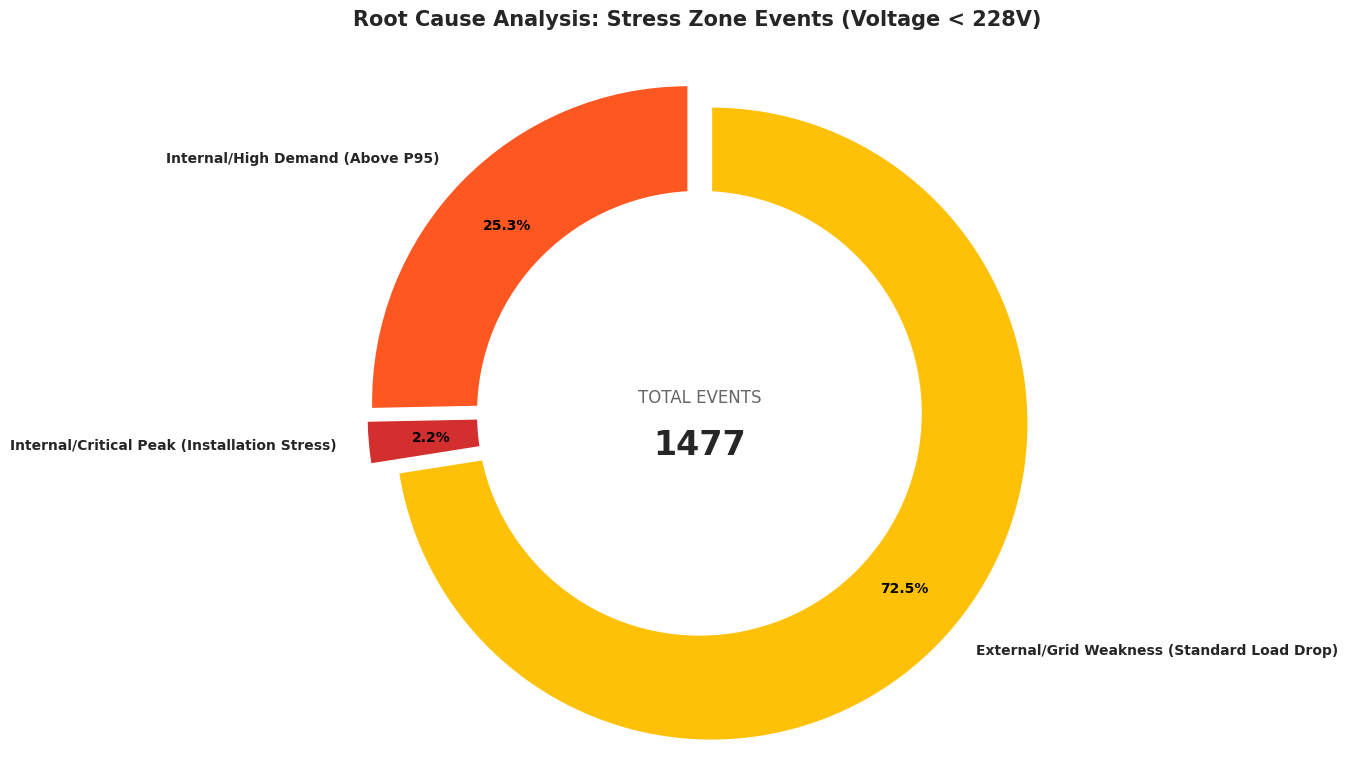


INSIGHTS PARA EL REPORTE TÉCNICO
- Internal/High Demand (Above P95): 374 min (25.3%)
- Internal/Critical Peak (Installation Stress): 32 min (2.2%)
- External/Grid Weakness (Standard Load Drop): 1071 min (72.5%)


In [32]:
import matplotlib.pyplot as plt
import os

# 1. Preparación de datos y cálculos estadísticos rápidos
# Filtramos y obtenemos el total para mostrarlo en el centro de la dona
stress_df = H4_Validation_Report.filter("technical_responsibility_tag != 'Healthy'")
total_stress_events = stress_df.count()

stress_data = stress_df \
    .groupBy("technical_responsibility_tag") \
    .count() \
    .toPandas()

# 2. Configuración de la gráfica (Usando el objeto 'fig' para evitar archivos en blanco)
fig, ax = plt.subplots(figsize=(12, 8))

# Colores específicos (Tu paleta técnica)
colors_dict = {
    'External/Grid Weakness (Standard Load Drop)': '#FFC107', 
    'Internal/High Demand (Above P95)': '#FF5722',           
    'Internal/Critical Peak (Installation Stress)': '#D32F2F', 
    'Mixed/Ambient Stress': '#9E9E9E'                         
}

current_colors = [colors_dict.get(x, '#17a2b8') for x in stress_data['technical_responsibility_tag']]

# Crear el gráfico de dona
wedges, texts, autotexts = ax.pie(
    stress_data['count'], 
    labels=stress_data['technical_responsibility_tag'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=current_colors,
    explode=[0.05] * len(stress_data),
    pctdistance=0.80,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)

# Estilizar los porcentajes para que se lean mejor
plt.setp(autotexts, size=10, color="black")

# 3. Añadir Información Central (KPI de Impacto)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax.add_artist(centre_circle)

# Texto central: Total de minutos/eventos detectados
ax.text(0, 0.05, 'TOTAL EVENTS', ha='center', va='center', fontsize=12, color='#666666')
ax.text(0, -0.10, f'{total_stress_events}', ha='center', va='center', fontsize=24, fontweight='bold')

plt.title('Root Cause Analysis: Stress Zone Events (Voltage < 228V)', fontsize=15, fontweight='bold', pad=20)
ax.axis('equal') 
plt.tight_layout()

# 4. Exportación robusta
win_user = os.popen("cmd.exe /c echo %USERNAME%").read().strip()
base_path = f"/mnt/c/Users/{win_user}/Documents/Data-Projects-Repo/03_SQL_Big_Data_Spark/03.01_CAPSTONE_Industrial_Energy_Analytics"
plot_path = os.path.join(base_path, "docs", "H4_root_cause_analysis.png")

# Asegurar que la carpeta existe
os.makedirs(os.path.dirname(plot_path), exist_ok=True)

# Guardar ANTES de mostrar
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico guardado con éxito en: {plot_path}")

plt.show()

# 5. Insight adicional para tu documentación (Markdown Ready)
print("\n" + "="*40)
print("INSIGHTS PARA EL REPORTE TÉCNICO")
print("="*40)
for index, row in stress_data.iterrows():
    percentage = (row['count'] / total_stress_events) * 100
    print(f"- {row['technical_responsibility_tag']}: {row['count']} min ({percentage:.1f}%)")

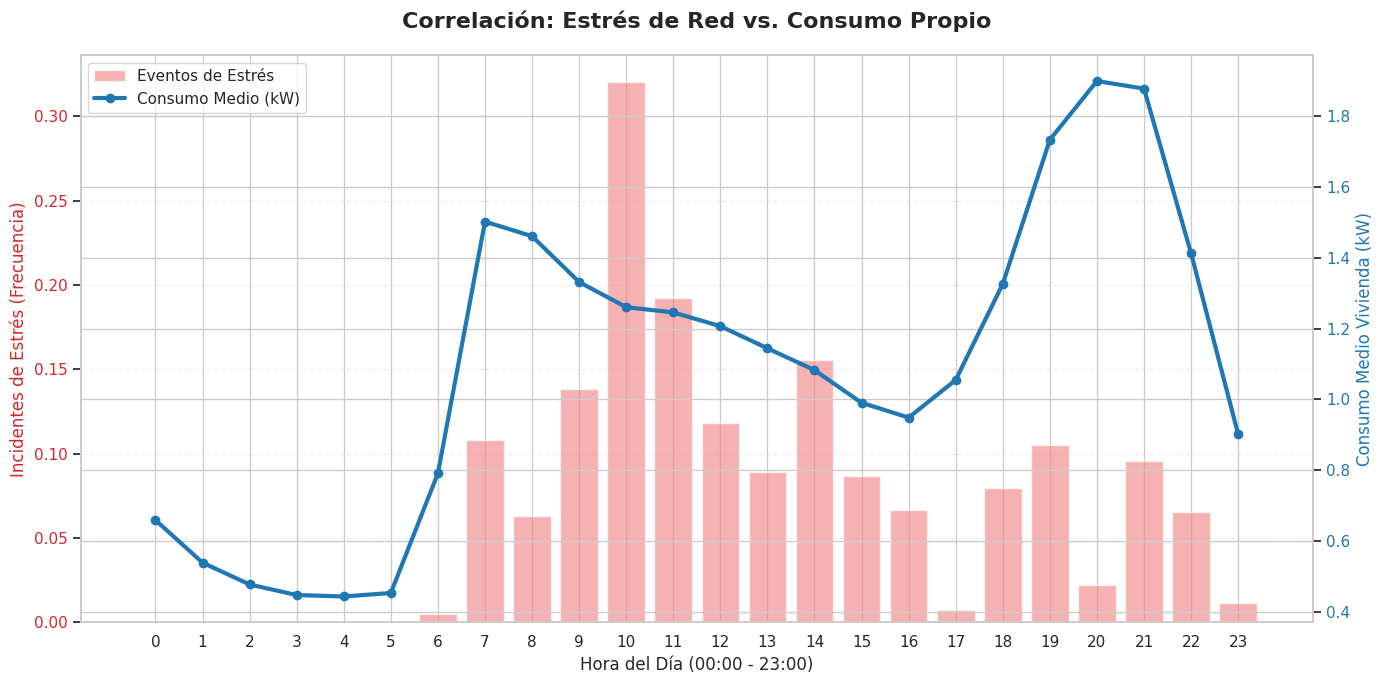

In [33]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import hour, col, avg

# 1. Agregamos los datos por hora: Contamos incidentes de estrés Y calculamos consumo medio
hourly_stats = H4_Validation_Report.groupBy(hour("Full_Timestamp").alias("hour")) \
    .agg(
        avg(col("is_stress_zone")).alias("stress_ratio"), # Frecuencia de estrés
        avg(col("power_kw")).alias("avg_consumption_kw"), # Consumo medio
        (avg(col("is_stress_zone")) * 100).alias("stress_events_count") # Para que la escala sea visible
    ) \
    .orderBy("hour") \
    .toPandas()

# 2. Configuración de la gráfica con DOBLE EJE (TwinX)
fig, ax1 = plt.subplots(figsize=(14, 7))

# EJE 1: Barras de Estrés
color_bars = 'lightcoral'
ax1.set_xlabel('Hora del Día (00:00 - 23:00)', fontsize=12)
ax1.set_ylabel('Incidentes de Estrés (Frecuencia)', color='tab:red', fontsize=12)
bars = ax1.bar(hourly_stats['hour'], hourly_stats['stress_events_count'], color=color_bars, alpha=0.6, label='Eventos de Estrés')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_xticks(range(0, 24))

# EJE 2: Línea de Consumo Medio (kW)
ax2 = ax1.twinx() # Creamos el segundo eje que comparte el mismo X
color_line = 'tab:blue'
ax2.set_ylabel('Consumo Medio Vivienda (kW)', color=color_line, fontsize=12)
ax2.plot(hourly_stats['hour'], hourly_stats['avg_consumption_kw'], color=color_line, marker='o', linewidth=3, label='Consumo Medio (kW)')
ax2.tick_params(axis='y', labelcolor=color_line)

# 3. Estética y Títulos
plt.title('Correlación: Estrés de Red vs. Consumo Propio', fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Añadimos una leyenda combinada
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()

# Exportar archivo

# Detectamos el usuario de Windows de forma anónima
win_user = os.popen("cmd.exe /c echo %USERNAME%").read().strip()

# Construimos la ruta 'puente' entre WSL y Windows
base_path = f"/mnt/c/Users/{win_user}/Documents/Data-Projects-Repo/03_SQL_Big_Data_Spark/03.01_CAPSTONE_Industrial_Energy_Analytics"

# Definimos las carpetas de destino
plot_path = os.path.join(base_path, "docs", "H4_correlation_stress.png")

# Guardar Gráfico
plt.savefig(plot_path, dpi=300, bbox_inches='tight')


plt.show()

---
>## 4. Conclusiones y valor de negocio

# 🏁 Resumen Ejecutivo: Auditoría Energética de Alta Precisión

Tras el procesamiento distribuido de más de **2 millones de registros** mediante el motor de cómputo **Apache Spark**, se presenta la síntesis final del comportamiento eléctrico de la unidad bajo estudio. Este análisis trasciende el monitoreo convencional para convertirse en una **auditoría forense de alta precisión**, permitiendo segmentar el gasto, mitigar riesgos técnicos y maximizar el ahorro económico.

---

## 📊 Comparativa de Impacto y Validación de Hipótesis
A continuación, se tabula el impacto de cada vector de análisis sobre la operatividad y la eficiencia de la instalación:

| Hipótesis | Estado | Factor Crítico Identificado | Impacto en Negocio / Ahorro | Relevancia Técnica |
| :--- | :---: | :--- | :--- | :--- |
| **H1: Simultaneidad** | ✅ Validada | Sobredimensionamiento estructural (Pico >10kW). | **Alto:** Reducción de término fijo al bajar a 6.9 kW. | Optimización de potencia contratada. |
| **H2: Outliers (Horno)** | ✅ Validada | Factor Humano (Olvido operativo el 05/06/2010). | **Medio:** Prevención de desperdicio energético (72% de ahorro). | NIALM (Firma de carga del activo). |
| **H3: Consumo Base** | ✅ **CRÍTICA** | Standby del **37.66%** (Ineficiencia masiva). | **Muy Alto:** Ahorro proyectado de **1,068 kWh/año**. | NILM: Desagregación de carga y perfilado de activos. |
| **H4: Estabilidad** | ⚠️ Parcial | Deficiencia en Red Externa (Distribuidora). | **Bajo (Económico) / Alto (Activos):** Vida útil. | Diagnóstico de calidad de suministro. |



---

## 🛠️ Conclusiones Transversales de Ingeniería

### 1. Arquitectura de Carga y Eficiencia Operativa
El análisis revela una instalación con una excelente salud de infraestructura interna (**H4**), pero con una gestión operativa deficiente (**H1, H2, H3**). La vivienda sufre de un "goteo" energético constante que representa más de un tercio de su consumo total. 

> **Hallazgo Clave (H3):** El consumo residual de 0.472 kW en circuitos generales. Mediante analítica NILM, se ha desglosado este valor en un standby ~0.35 kW y una carga cíclica de refrigeración secundaria (presumiblemente un arcón o minibar fuera de la cocina) con un Duty Cycle del 19.78%. Aunque este ciclo de trabajo indica una salud mecánica óptima (inferior al umbral crítico del 25%), la elevada potencia de pico (0.44 kW) revela un equipo tecnológicamente obsoleto. Se descarta el mantenimiento preventivo en favor de una sustitución estratégica por tecnología Inverter, lo que reduciría el standby total a 0.35 kW y generaría un ahorro de 1,068 kWh/año, garantizando un ROI de 1.9 años."

### 2. Mitigación de Riesgos y Seguridad de Activos
La identificación forense del evento del horno (**H2**) demuestra que el riesgo no es técnico (averías), sino de comportamiento. Integrar algoritmos de detección de anomalías basados en las firmas eléctricas obtenidas permitiría implementar sistemas de **Smart Home** que corten el suministro ante patrones de olvido, protegiendo la instalación de estreses térmicos innecesarios como el detectado (83% de capacidad nominal durante 4 horas).

### 3. Optimización Financiera (Cost-Benefit Analysis)
La estrategia propuesta se divide en dos ejes:

* **Ahorro Pasivo:** La reducción de potencia contratada a 6.9 kW (H1) se define como una medida de CapEx 0 (inversión cero). Al demostrar mediante el análisis de simultaneidad que el umbral de 10 kW es innecesario, se genera un ahorro neto en el término fijo de la factura de forma inmediata y recurrente.
* **Ahorro Activo:** La analítica NILM proyecta un ahorro de 1,068 kWh/año con un ROI de 1.9 años. Este plan de eficiencia se desglosa en dos fases estratégicas:
    * **Sustitución por Obsolescencia:** Reemplazo del frigorífico secundario en el circuito de "Otros" (Salto ~0.44 kW). Su ineficiencia tecnológica exige tecnología Inverter.
    * **Gestión de Standby Residual:** Instalación de Smart Kill-Switches para eliminar el suelo de 0.20 kW en circuitos generales. Esta medida es la única vía para alcanzar el objetivo técnico de 0.15 kW de consumo basal.

---

## 🚀 Roadmap de Implementación Recomendado
Basado en la evidencia de los datos, el plan de acción post-notebook es:

**Inmediato (Gestión de Suministro y Carga):**
* Solicitar bajada de **potencia contratada a 6.9 kW (H1)**. Generará un ahorro mensual recurrente e inmediato sin inversión de capital (**CapEx 0**).
* **Desplazar el uso de lavandería** fuera del horario crítico de cena (18:00-22:00).

**Corto Plazo (Infraestructura y Auditoría de Activos):**
* **Sustituir el equipo frigorífico** instalado en la linea de Otros por tecnología Inverter
* **Protección de Hardware:** Instalar un SAI de doble conversión para aislar equipos críticos del estrés eléctrico identificado en la H4.

**Medio Plazo (Eficiencia Estructural y Reclamación):**
* **Eliminación de "Cargas Fantasma":** Implementar Smart Kill-Switches para erradicar el suelo de standby de 0.20 kW, bajando el ratio del 37% al <10%.
* **Acción Legal Basada en estudio de datos (H4):** Generación de un informe técnico pericial fundamentado en el procesamiento de 2.075.259 registros mediante Big Data Spark. La evidencia central es la exposición recurrente a la "Zona de Estrés" (<228V), detectada especialmente en franjas de baja carga interna. Se alega que, aunque los promedios minutales son legales, suponen la "punta del iceberg" de fluctuaciones instantáneas mucho más graves (sospecha de caídas a <215V) que la granularidad actual oculta. Este informe técnico servirá para exigir a la distribuidora una auditoría con instrumental de Clase A y el reajuste del transformador, basándose en la degradación por fatiga térmica acumulada en los equipos de la vivienda.

---
